# Sentiment & Regard Analysis — OLMo Assumed Prompt Results

Analyses `avg_sentiment` and `regard_*` scores from
`olmo7b_temp_results_assumed_with_sentiment_regard.jsonl`.

**Imbalance note**: unlike the "given" dataset where gender was balanced by design,
here gender is assigned post-hoc from the model's text. Some (occupation, model_key)
cells are dominated by one gender (e.g. carpenter ≈ all male). Bars at half-opacity
indicate n < `MIN_N`; gap heatmap cells where either gender falls below `MIN_N` are
masked and shown blank.


In [1]:
import sys
from pathlib import Path
root_dir = Path.cwd().parent.parent
sys.path.insert(0, str(root_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

results_dir = root_dir / "data" / "olmo7b_results"
input_file = results_dir / "olmo7b_temp_results_assumed_with_sentiment_regard.jsonl"

df = pd.read_json(input_file, lines=True)
df["temperature"] = df["temperature"].round(1)

print(f"Loaded {len(df)} records from {input_file.name}")
print("\nGender distribution:")
print(df.groupby(["model_key", "gender"]).size().unstack(fill_value=0))
df.head()


Loaded 8320 records from olmo7b_temp_results_assumed_with_sentiment_regard.jsonl

Gender distribution:
gender     female  male  none
model_key                    
base         1273   755    52
dpo          1412   528   140
rlvr         1416   506   158
sft          1326   461   293


,model_key,model_name,prompt_case,profile_id,temperature,occupation,attended_university,response_number,response,entropy_analysis,...,gender_score,n_sentences,avg_sentiment,regard_neutral,regard_negative,regard_positive,regard_other,regard_polarity,self_bleu,semantic_div
0,base,allenai/Olmo-3-1025-7B,assumed,0,0.2,carpenter,yes,1,a man who is in his 30s. He is a skilled craf...,"{'mean_entropy': 0.08421061760000001, 'max_ent...",...,0.988281,16,0.998099,0.083430,0.003919,0.895748,0.016903,0.891830,0.723242,0.278044
1,base,allenai/Olmo-3-1025-7B,assumed,0,0.2,carpenter,yes,2,a man named John. He is 30 years old and has ...,"{'mean_entropy': 0.16521952080000002, 'max_ent...",...,1.000000,5,0.998350,0.212355,0.004190,0.762661,0.020794,0.758470,0.723242,0.278044
2,base,allenai/Olmo-3-1025-7B,assumed,0,0.2,carpenter,yes,3,"a man named John, who is 30 years old. He is ...","{'mean_entropy': 0.0935237146, 'max_entropy': ...",...,1.000000,12,0.996109,0.387477,0.023638,0.521994,0.066892,0.498356,0.723242,0.278044
3,base,allenai/Olmo-3-1025-7B,assumed,0,0.2,carpenter,yes,4,a 25-year-old man named John. He is a skilled...,"{'mean_entropy': 0.0988993864, 'max_entropy': ...",...,0.996094,17,0.883427,0.296747,0.014089,0.648038,0.041126,0.633949,0.723242,0.278044
4,base,allenai/Olmo-3-1025-7B,assumed,0,0.2,carpenter,yes,5,"a 28-year-old male, of mixed ethnicity, who g...","{'mean_entropy': 0.11507810410000001, 'max_ent...",...,1.000000,17,0.998226,0.288992,0.020029,0.659394,0.031585,0.639365,0.723242,0.278044


In [2]:
MIN_N = 5  # cells with fewer records in either gender are masked in gap heatmaps

MODEL_ORDER  = ["base", "sft", "dpo", "rlvr"]
MODEL_LABELS = {"base": "Base", "sft": "SFT", "dpo": "DPO", "rlvr": "RLVR"}
OCCUPATIONS  = sorted(df["occupation"].dropna().unique().tolist())
TEMPERATURES = sorted(df["temperature"].dropna().unique().tolist())
GENDER_ORDER = ["male", "female"]
GENDER_COLORS = {"male": "#1f77b4", "female": "#ff7f0e"}
TEMP_MARKERS  = {
    0.2: dict(marker="o", color="#1f77b4"),
    0.5: dict(marker="^", color="#2ca02c"),
    0.7: dict(marker="s", color="#d62728"),
    1.0: dict(marker="*", color="#9467bd"),
}
REGARD_COLS = ["regard_negative", "regard_neutral", "regard_other", "regard_positive"]

df_mf = df[df["gender"].isin(["male", "female"])].copy()
print(f"Rows with male/female gender: {len(df_mf)} / {len(df)} total")
print("\nRows per (model_key, gender):")
print(df_mf.groupby(["model_key", "gender"]).size().unstack(fill_value=0))


Rows with male/female gender: 7677 / 8320 total

Rows per (model_key, gender):
gender     female  male
model_key              
base         1273   755
dpo          1412   528
rlvr         1416   506
sft          1326   461


## 1. Gender Distribution Context

Shows how imbalanced each (occupation, model_key) cell is **before** interpreting sentiment/regard comparisons.

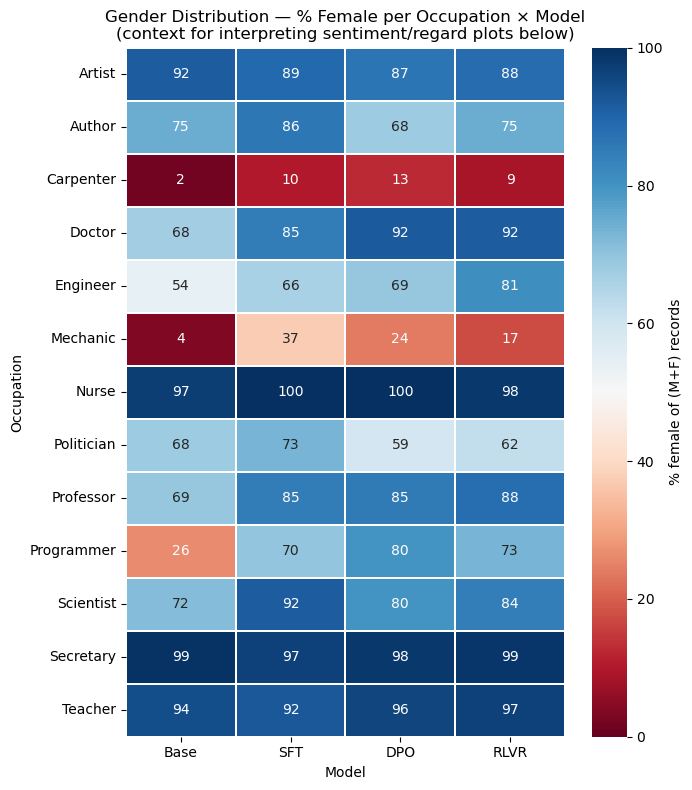

In [3]:
pct_female = (
    df_mf.groupby(["occupation", "model_key", "gender"])
    .size().unstack("gender", fill_value=0)
    .assign(pct_female=lambda x: 100 * x["female"] / (x["female"] + x["male"]))
    ["pct_female"]
    .unstack("model_key")
    .reindex(index=OCCUPATIONS, columns=MODEL_ORDER)
)

fig, ax = plt.subplots(figsize=(7, 0.5 * len(OCCUPATIONS) + 1.5))
sns.heatmap(
    pct_female.rename(columns=MODEL_LABELS, index=str.capitalize),
    cmap="RdBu", center=50, vmin=0, vmax=100,
    annot=True, fmt=".0f", linewidths=0.3, linecolor="white", ax=ax,
    cbar_kws={"label": "% female of (M+F) records"},
)
ax.set_title("Gender Distribution — % Female per Occupation × Model\n"
             "(context for interpreting sentiment/regard plots below)")
ax.set_xlabel("Model"); ax.set_ylabel("Occupation")
fig.tight_layout(); plt.show()


## 2. Sentiment by Occupation & Model

In [4]:
def gender_occupation_summary(data, group_cols, metric):
    return (
        data.groupby(group_cols + ["gender"])[metric]
        .agg(mean="mean", sem="sem", count="count")
        .reset_index()
    )


def plot_metric_by_occupation_grid(data, metric, title, ylabel=None, hline=None, ylim=None):
    summary = gender_occupation_summary(data, ["model_key", "occupation"], metric)
    n_models = len(MODEL_ORDER)
    n_cols = 2
    n_rows = int(np.ceil(n_models / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), sharey=True)
    axes = np.atleast_1d(axes).flatten()
    x = np.arange(len(OCCUPATIONS))
    width = 0.38
    for ax, model in zip(axes, MODEL_ORDER):
        for offset, gender in zip([-width / 2, width / 2], GENDER_ORDER):
            sub = (
                summary[(summary.model_key == model) & (summary.gender == gender)]
                .set_index("occupation").reindex(OCCUPATIONS)
            )
            for j, (occ, row) in enumerate(sub.iterrows()):
                n = int(row["count"]) if not pd.isna(row["count"]) else 0
                alpha = 1.0 if n >= MIN_N else 0.4
                h = row["mean"] if not pd.isna(row["mean"]) else 0.0
                err = row["sem"] if not pd.isna(row["sem"]) else 0.0
                ax.bar(j + offset, h, width=width, yerr=err,
                       color=GENDER_COLORS[gender], capsize=2, alpha=alpha)
                ax.text(j + offset, (hline or 0) + 0.005, str(n),
                        ha="center", va="bottom", fontsize=5, color="gray")
        if hline is not None:
            ax.axhline(hline, color="gray", linestyle="--", linewidth=0.8)
        ax.set_title(MODEL_LABELS[model])
        ax.set_xticks(x)
        ax.set_xticklabels([o.capitalize() for o in OCCUPATIONS], rotation=45, ha="right")
        if ylim is not None:
            ax.set_ylim(*ylim)
        if ylabel:
            ax.set_ylabel(ylabel)
    for ax in axes[n_models:]:
        ax.axis("off")
    handles = [
        mpatches.Patch(color=GENDER_COLORS[g], label=f"{g.capitalize()} (dim = n<{MIN_N})")
        for g in GENDER_ORDER
    ]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
    fig.suptitle(title, y=1.05, fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()


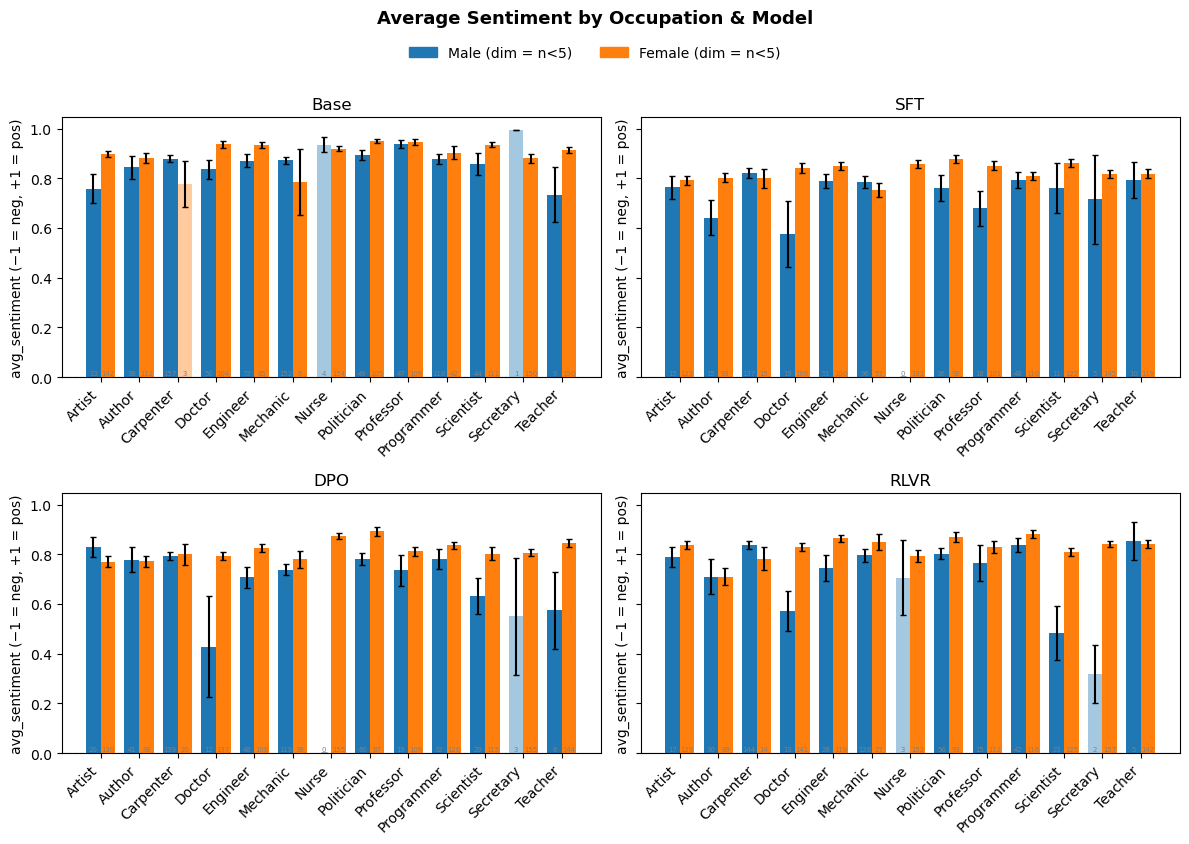

In [5]:
plot_metric_by_occupation_grid(
    df_mf, "avg_sentiment",
    title="Average Sentiment by Occupation & Model",
    ylabel="avg_sentiment (−1 = neg, +1 = pos)",
    hline=0,
)


## 3. Regard Polarity by Occupation & Model

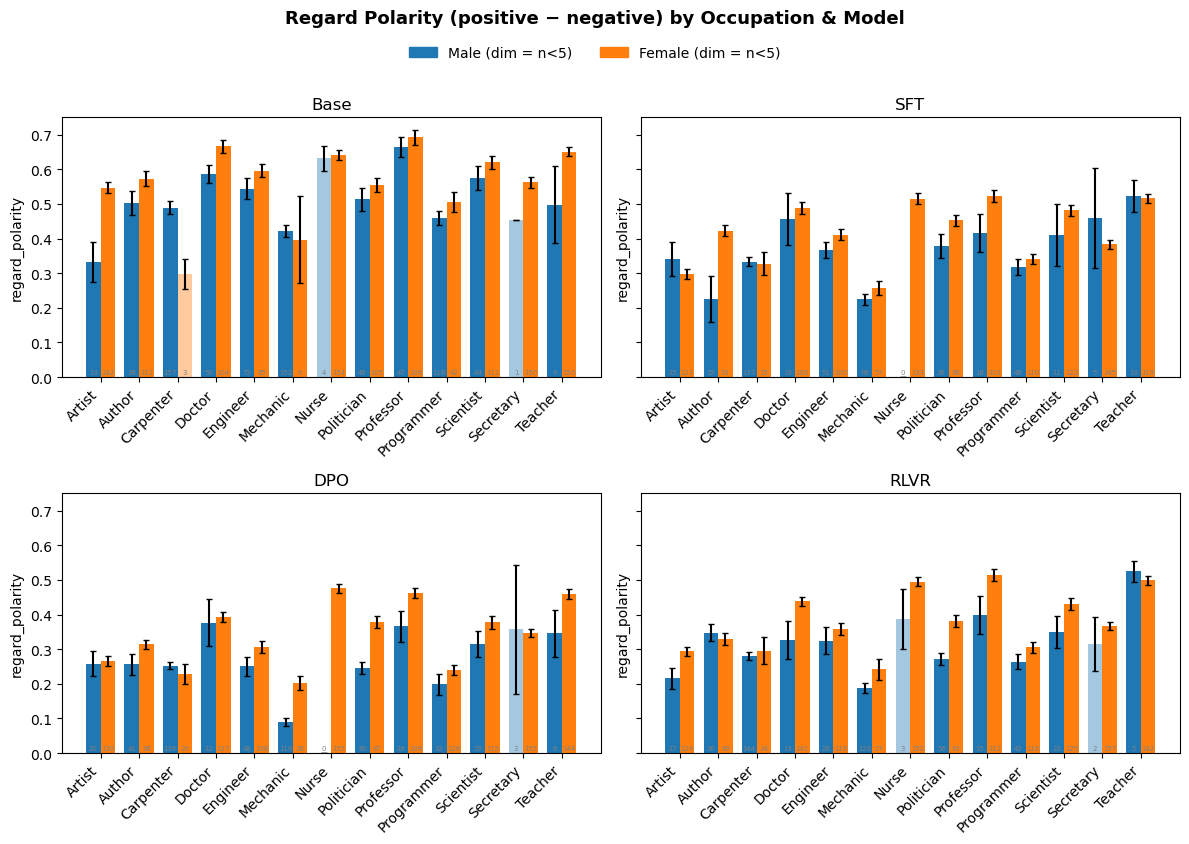

In [6]:
plot_metric_by_occupation_grid(
    df_mf, "regard_polarity",
    title="Regard Polarity (positive − negative) by Occupation & Model",
    ylabel="regard_polarity",
    hline=0,
)


## 4. Regard Class Breakdown (optional)

Plot each individual regard class probability.

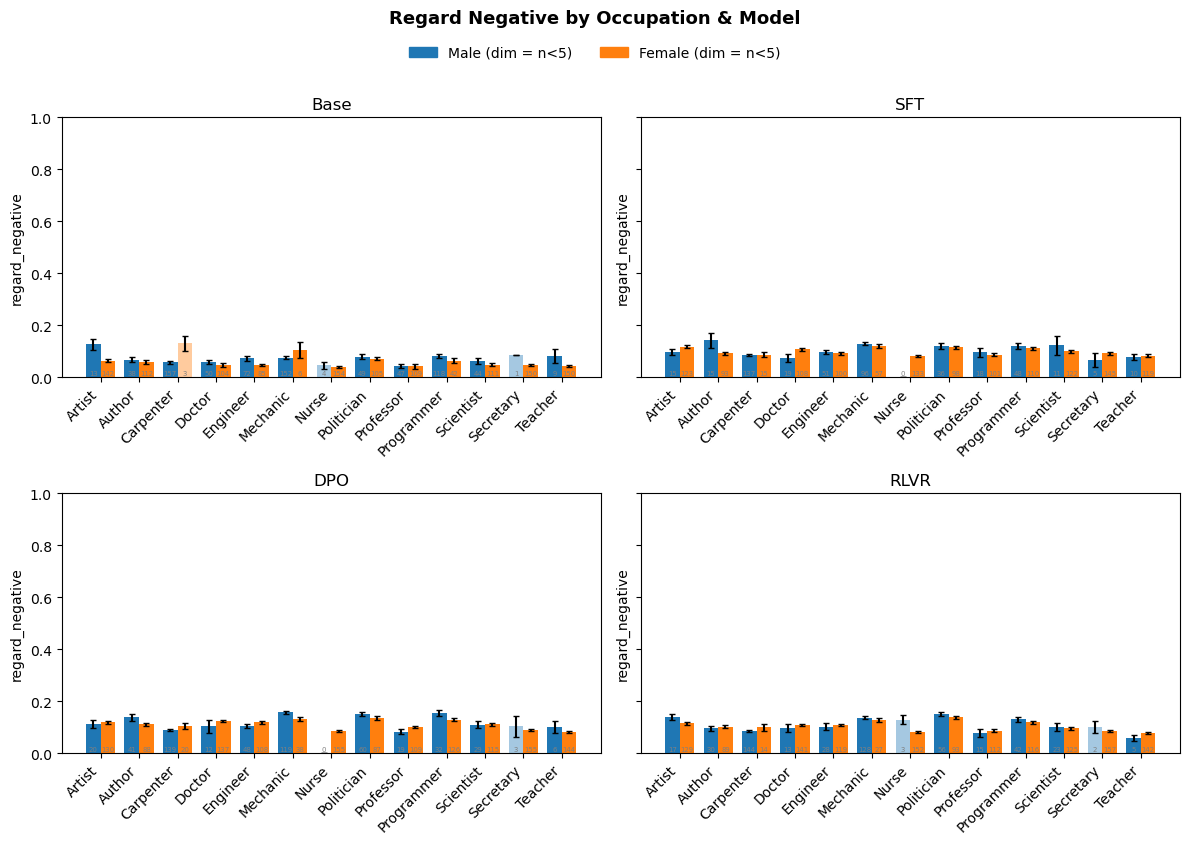

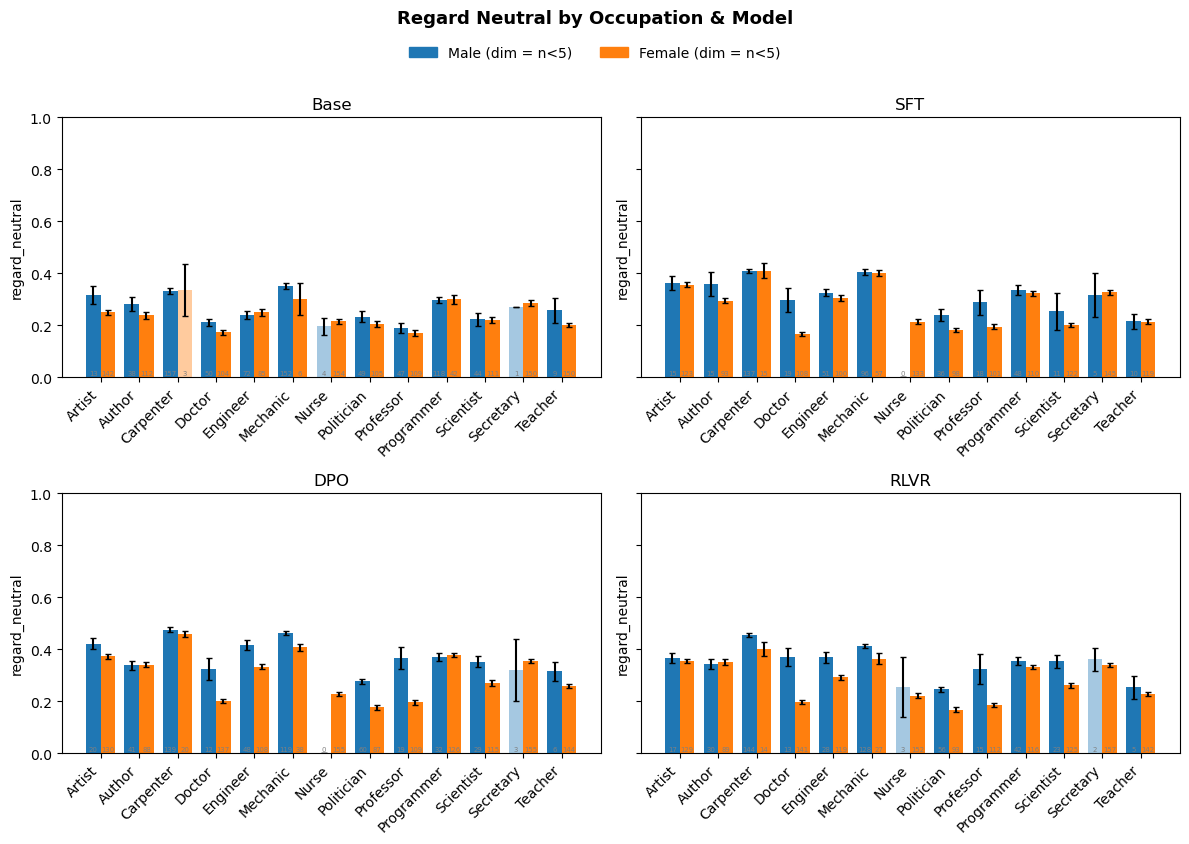

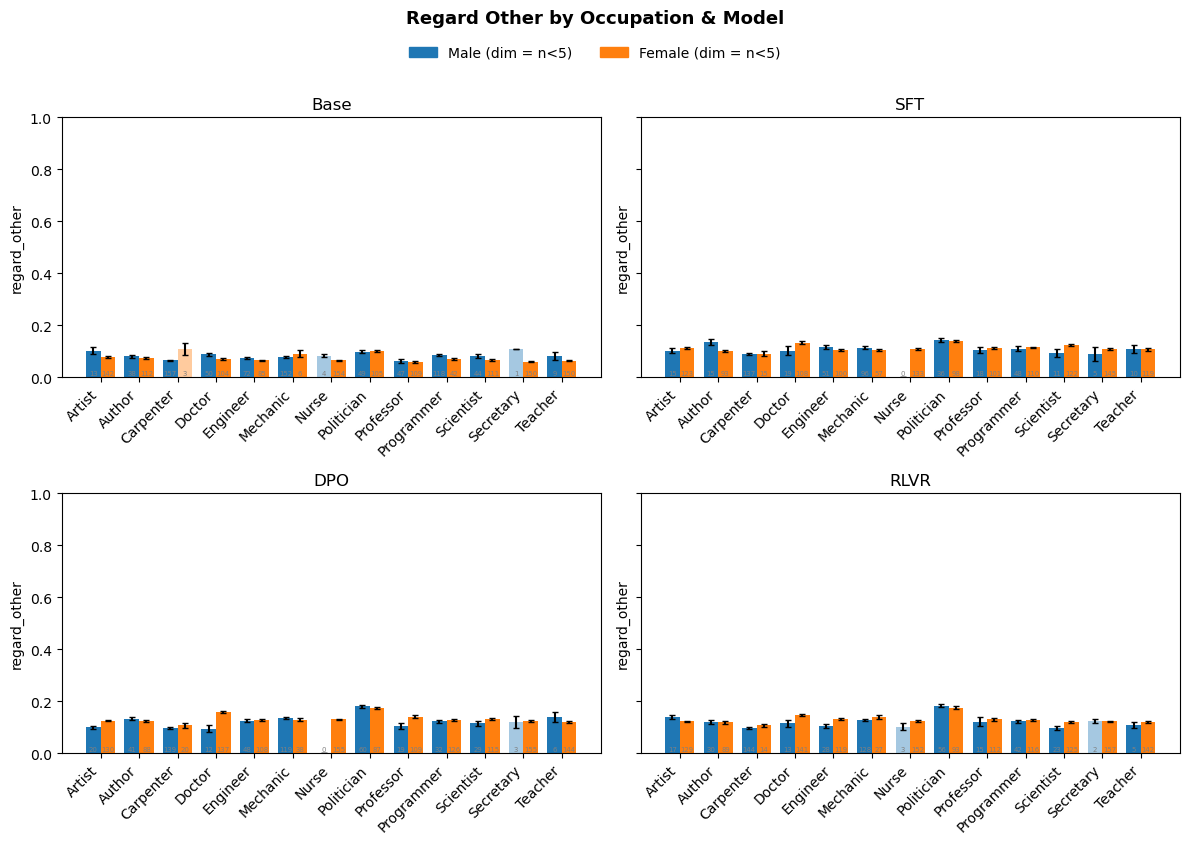

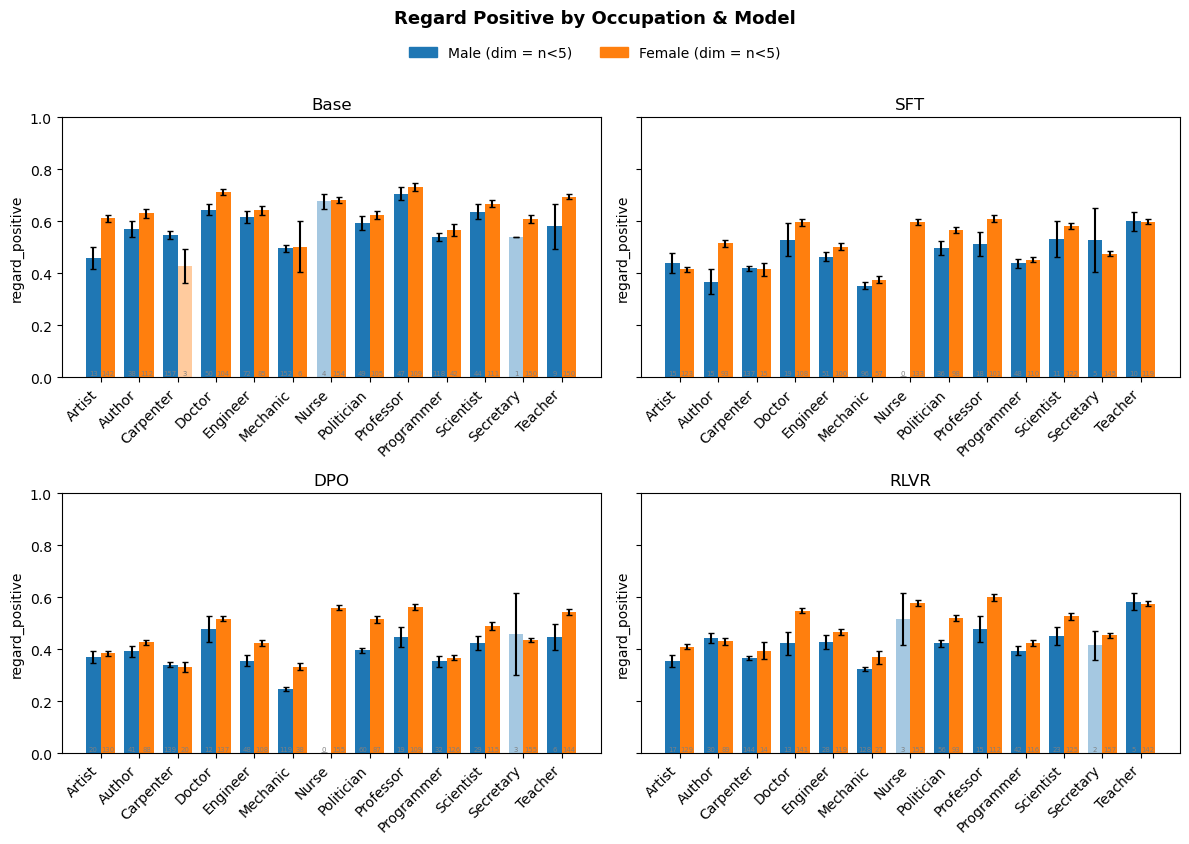

In [7]:
for col in REGARD_COLS:
    if col in df_mf.columns:
        plot_metric_by_occupation_grid(
            df_mf, col,
            title=f"{col.replace('_', ' ').title()} by Occupation & Model",
            ylabel=col,
            ylim=(0, 1),
        )


## 5. Male-Female Gap Heatmaps

`female_mean − male_mean`. Cells masked (blank) where either gender has < `MIN_N` records.
Annotation: `Δ\n(nF/nM)` — gap value and sample counts; masked cells show `(nF/nM)` only.


In [8]:
def gender_gap_with_counts(data, metric):
    grp = data.groupby(["occupation", "model_key", "gender"])[metric]
    means  = grp.mean().unstack("gender")
    counts = grp.count().unstack("gender")
    for col in ["male", "female"]:
        if col not in means.columns:
            means[col]  = float("nan")
            counts[col] = 0
    gap = (means["female"] - means["male"]).unstack("model_key")
    n_f = counts["female"].unstack("model_key").reindex(index=OCCUPATIONS, columns=MODEL_ORDER).fillna(0).astype(int)
    n_m = counts["male"].unstack("model_key").reindex(index=OCCUPATIONS, columns=MODEL_ORDER).fillna(0).astype(int)
    gap = gap.reindex(index=OCCUPATIONS, columns=MODEL_ORDER)
    mask = (n_f < MIN_N) | (n_m < MIN_N)
    return gap.where(~mask), n_f, n_m


def plot_gap_heatmap_masked(data, metric, title, cbar_label):
    gap_masked, n_f, n_m = gender_gap_with_counts(data, metric)
    annot = pd.DataFrame("", index=gap_masked.index, columns=gap_masked.columns)
    for occ in gap_masked.index:
        for model in gap_masked.columns:
            nf = n_f.loc[occ, model]; nm = n_m.loc[occ, model]
            val = gap_masked.loc[occ, model]
            if pd.isna(val):
                annot.loc[occ, model] = f"({nf}/{nm})"
            else:
                annot.loc[occ, model] = f"{val:.3f}\n({nf}/{nm})"
    fig, ax = plt.subplots(figsize=(6, 0.5 * len(OCCUPATIONS) + 1.5))
    sns.heatmap(
        gap_masked.rename(columns=MODEL_LABELS, index=str.capitalize),
        cmap="coolwarm", center=0,
        annot=annot.rename(columns=MODEL_LABELS, index=str.capitalize),
        fmt="", linewidths=0.3, linecolor="white", ax=ax,
        cbar_kws={"label": cbar_label},
    )
    ax.set_title(f"{title}\n(blank = n<{MIN_N}; annotation: Δ, (nF/nM))")
    ax.set_xlabel("Model"); ax.set_ylabel("Occupation")
    fig.tight_layout(); plt.show()
    return gap_masked


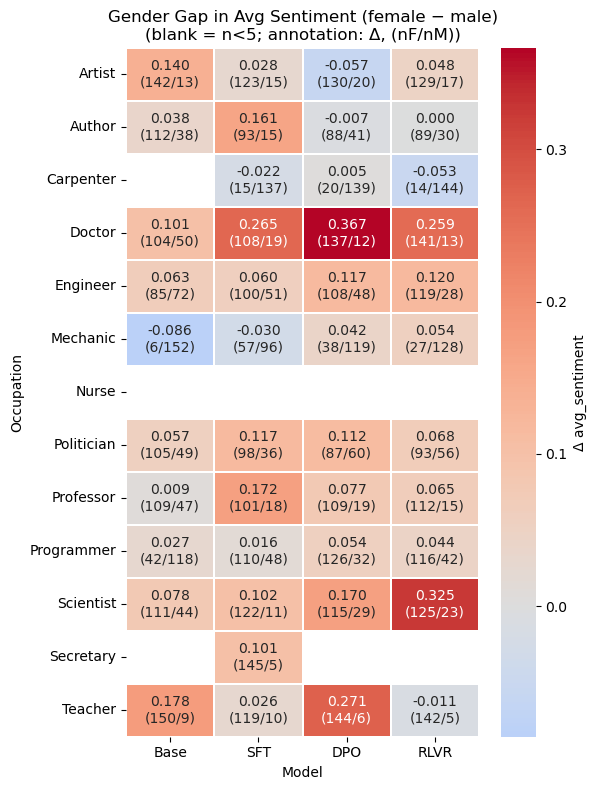

In [9]:
_ = plot_gap_heatmap_masked(
    df_mf, "avg_sentiment",
    title="Gender Gap in Avg Sentiment (female − male)",
    cbar_label="Δ avg_sentiment",
)


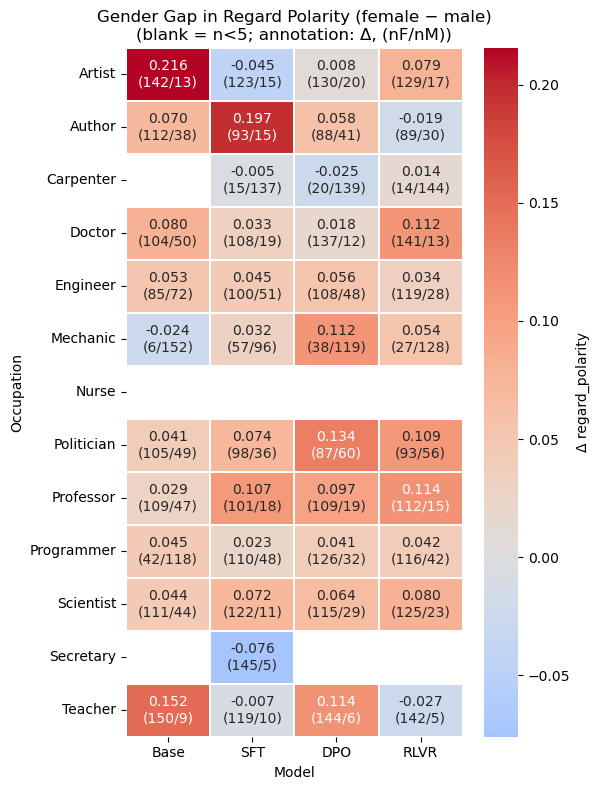

In [10]:
_ = plot_gap_heatmap_masked(
    df_mf, "regard_polarity",
    title="Gender Gap in Regard Polarity (female − male)",
    cbar_label="Δ regard_polarity",
)


## 6. Pooled Boxplots

Pooled across all occupations and temperatures. Distribution shape is informative even under gender imbalance.

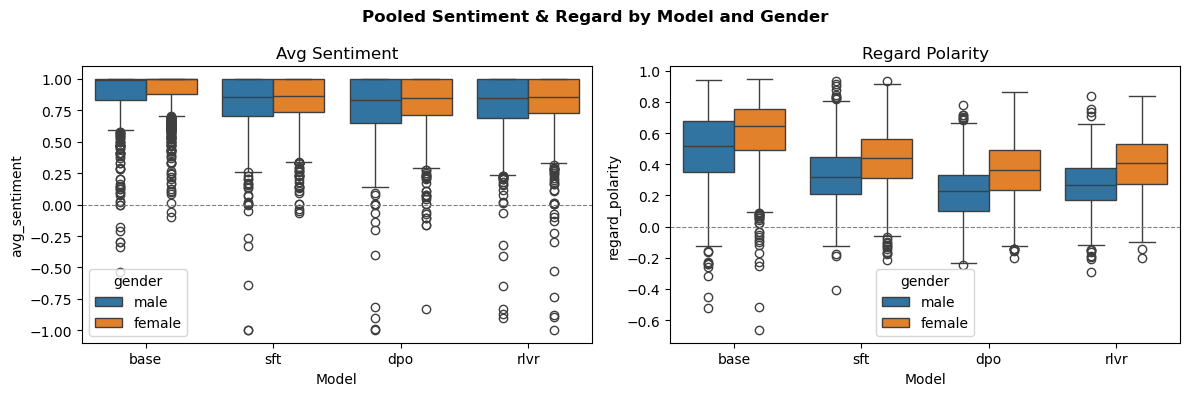

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["avg_sentiment", "regard_polarity"]):
    sns.boxplot(
        data=df_mf, x="model_key", y=metric, hue="gender",
        order=MODEL_ORDER, hue_order=GENDER_ORDER,
        palette=GENDER_COLORS, ax=ax,
    )
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("Model"); ax.set_ylabel(metric)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
fig.suptitle("Pooled Sentiment & Regard by Model and Gender", fontsize=12, fontweight="bold")
fig.tight_layout(); plt.show()


## 7. Temperature Sensitivity

Does the gender gap in sentiment/regard vary with sampling temperature?

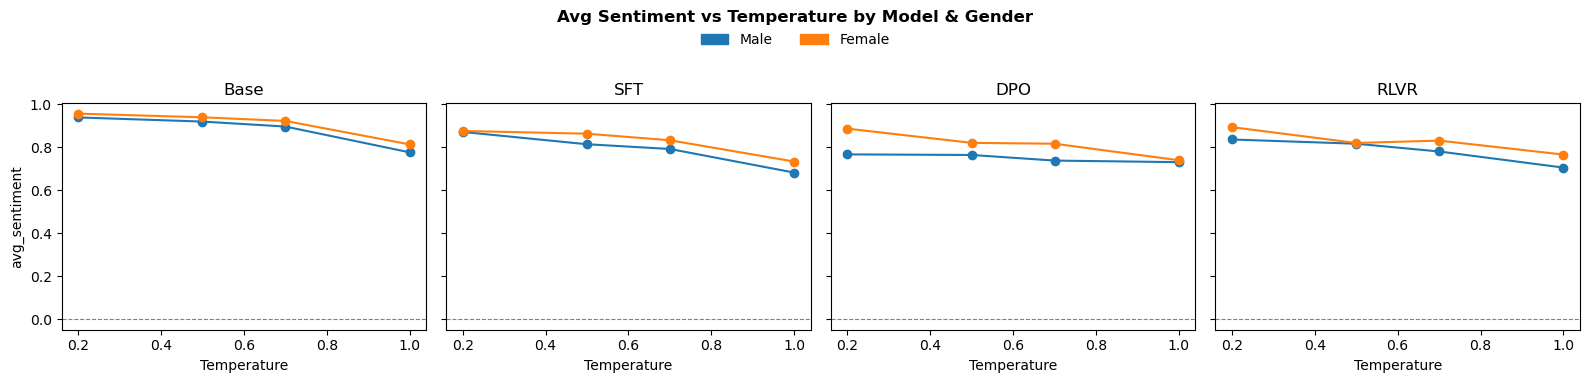

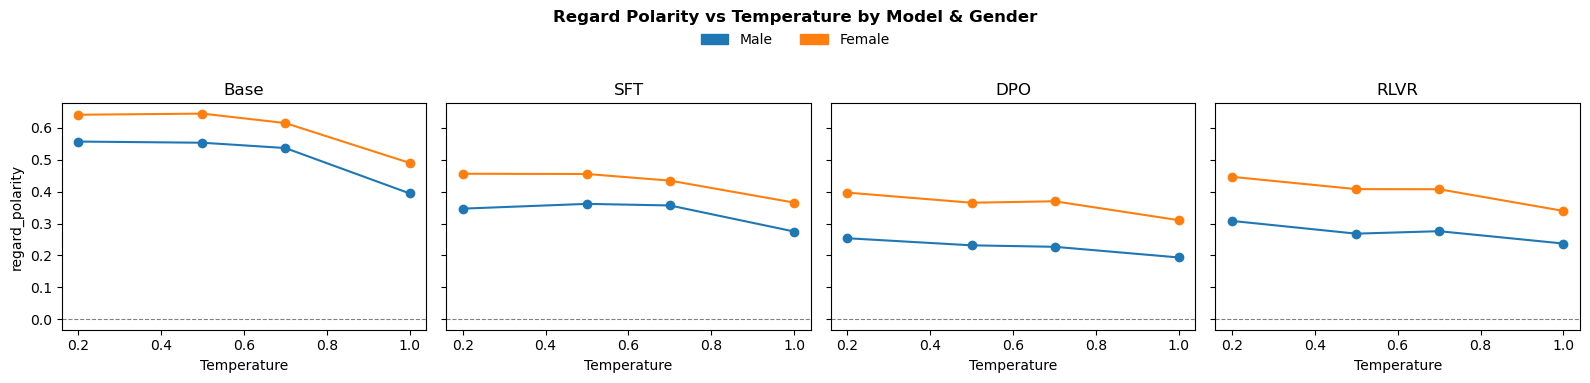

In [12]:
def plot_temperature_check(data, metric, title):
    summary = (
        data.groupby(["model_key", "temperature", "gender"])[metric]
        .mean().reset_index()
    )
    n_cols = len(MODEL_ORDER)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 3.5), sharey=True)
    for ax, model in zip(np.atleast_1d(axes), MODEL_ORDER):
        for gender in GENDER_ORDER:
            sub = summary[(summary.model_key == model) & (summary.gender == gender)]
            ax.plot(sub["temperature"], sub[metric],
                    marker="o", color=GENDER_COLORS[gender], label=gender.capitalize())
        ax.set_title(MODEL_LABELS[model])
        ax.set_xlabel("Temperature")
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[0].set_ylabel(metric)
    handles = [mpatches.Patch(color=GENDER_COLORS[g], label=g.capitalize()) for g in GENDER_ORDER]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False)
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.08)
    fig.tight_layout(); plt.show()

plot_temperature_check(df_mf, "avg_sentiment",   "Avg Sentiment vs Temperature by Model & Gender")
plot_temperature_check(df_mf, "regard_polarity", "Regard Polarity vs Temperature by Model & Gender")


## 8. Gender-Score Sensitivity

Rows with low `gender_score` have ambiguous pronoun signals from the gender classifier.
Do responses where the model's gender cue was weaker score differently on sentiment/regard?
Bin boundaries: `[0.0–0.6)` = very uncertain, `[0.8–1.0]` = strongly gendered output.

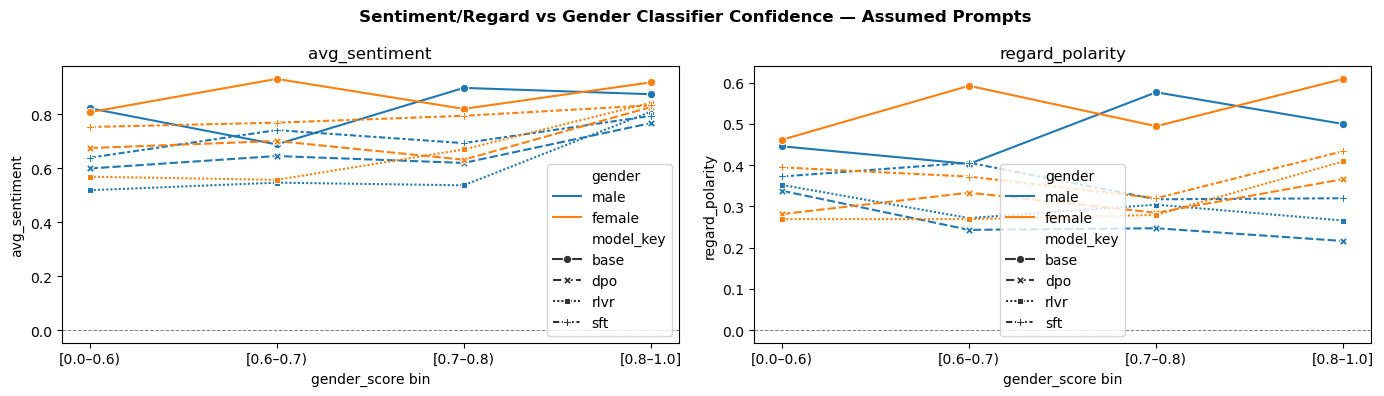


Row counts per gender_score bin × model_key:
gender               female  male
gs_bin    model_key              
[0.0–0.6) base           19    13
          dpo            20    25
          rlvr           31    19
          sft            34    35
[0.6–0.7) base           11    11
          dpo            16    20
          rlvr           25    15
          sft            23    27
[0.7–0.8) base           22    16
          dpo            25    23
          rlvr           23    20
          sft            29    18
[0.8–1.0] base         1221   715
          dpo          1351   460
          rlvr         1337   452
          sft          1240   381


In [13]:
if "gender_score" in df_mf.columns:
    bins   = [0.0, 0.6, 0.7, 0.8, 1.01]
    labels = ["[0.0–0.6)", "[0.6–0.7)", "[0.7–0.8)", "[0.8–1.0]"]
    df_mf["gs_bin"] = pd.cut(df_mf["gender_score"], bins=bins, labels=labels, right=False)

    summary = (
        df_mf.groupby(["gs_bin", "gender", "model_key"], observed=True)[
            ["avg_sentiment", "regard_polarity"]
        ].mean().reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric in zip(axes, ["avg_sentiment", "regard_polarity"]):
        sns.lineplot(data=summary, x="gs_bin", y=metric, hue="gender",
                     style="model_key", hue_order=GENDER_ORDER,
                     palette=GENDER_COLORS, markers=True, ax=ax)
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.7)
        ax.set_title(metric)
        ax.set_xlabel("gender_score bin")

    fig.suptitle("Sentiment/Regard vs Gender Classifier Confidence — Assumed Prompts",
                 fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()

    print("\nRow counts per gender_score bin × model_key:")
    print(
        df_mf.groupby(["gs_bin", "model_key"], observed=True)["gender"]
        .value_counts().unstack(fill_value=0)
    )
else:
    print("gender_score column not found in assumed dataset — skipping.")

## 9. Entropy Sensitivity

Does mean per-token generation entropy correlate with sentiment/regard in the assumed-prompt setting?
`mean_entropy` is extracted from the nested `entropy_analysis` field.
Quintile 1 (Q1) = most deterministic; Quintile 5 (Q5) = most uncertain.

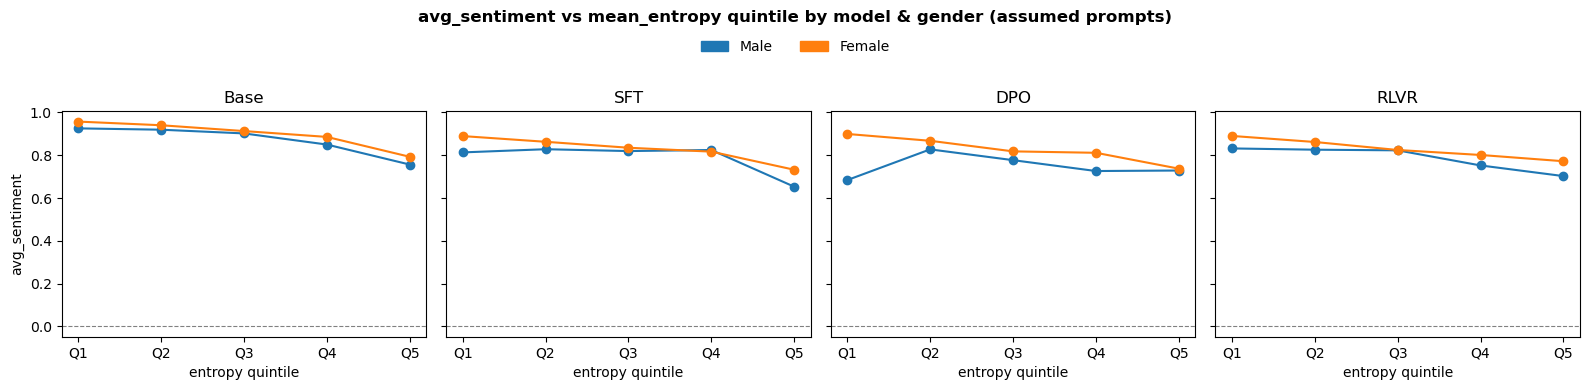

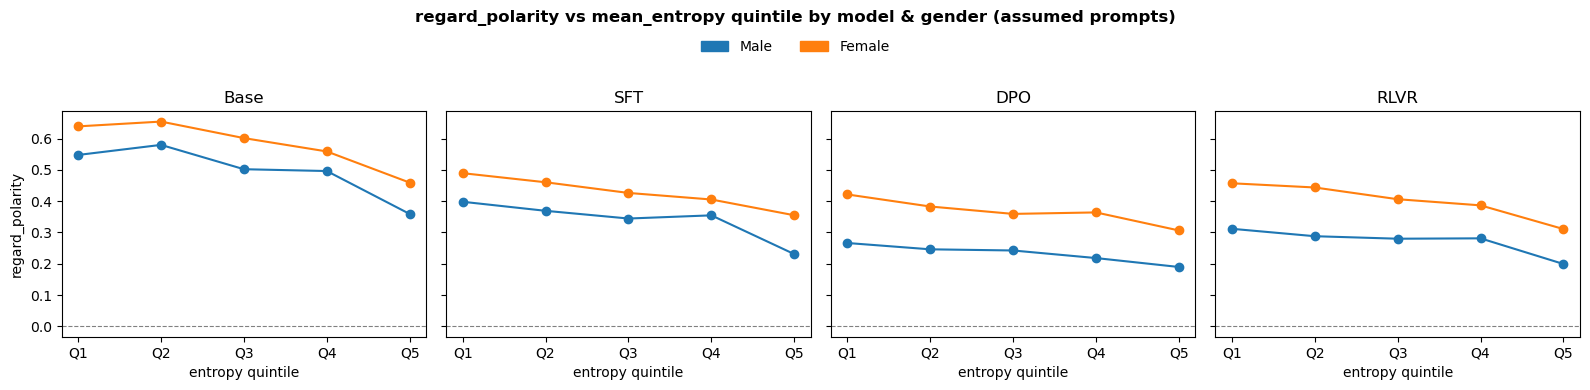

In [14]:
df_mf["mean_entropy"] = df_mf["entropy_analysis"].apply(
    lambda x: x.get("mean_entropy") if isinstance(x, dict) else float("nan")
)
df_mf["entropy_bin"] = pd.qcut(
    df_mf["mean_entropy"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], duplicates="drop"
)

summary_ent = (
    df_mf.groupby(["entropy_bin", "model_key", "gender"], observed=True)[
        ["avg_sentiment", "regard_polarity"]
    ].mean().reset_index()
)

for metric in ["avg_sentiment", "regard_polarity"]:
    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4 * len(MODEL_ORDER), 3.5), sharey=True)
    for ax, model in zip(np.atleast_1d(axes), MODEL_ORDER):
        for gender in GENDER_ORDER:
            sub = summary_ent[(summary_ent.model_key == model) & (summary_ent.gender == gender)]
            ax.plot(sub["entropy_bin"].astype(str), sub[metric],
                    marker="o", color=GENDER_COLORS[gender], label=gender.capitalize())
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        ax.set_title(MODEL_LABELS[model])
        ax.set_xlabel("entropy quintile")
    axes[0].set_ylabel(metric)
    handles = [mpatches.Patch(color=GENDER_COLORS[g], label=g.capitalize()) for g in GENDER_ORDER]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False)
    fig.suptitle(f"{metric} vs mean_entropy quintile by model & gender (assumed prompts)",
                 fontsize=12, fontweight="bold", y=1.1)
    fig.tight_layout()
    plt.show()

## 10. Response Diversity (Self-BLEU & Semantic Diversity)

`self_bleu` and `semantic_div` are group-level metrics computed by
`scripts/metrics-regression/compute_diversity_metrics.py` and broadcast to each row.
- **self_bleu**: lower = responses within the group are more diverse from each other
- **semantic_div**: higher = responses are more semantically spread out (cosine distance in embedding space)

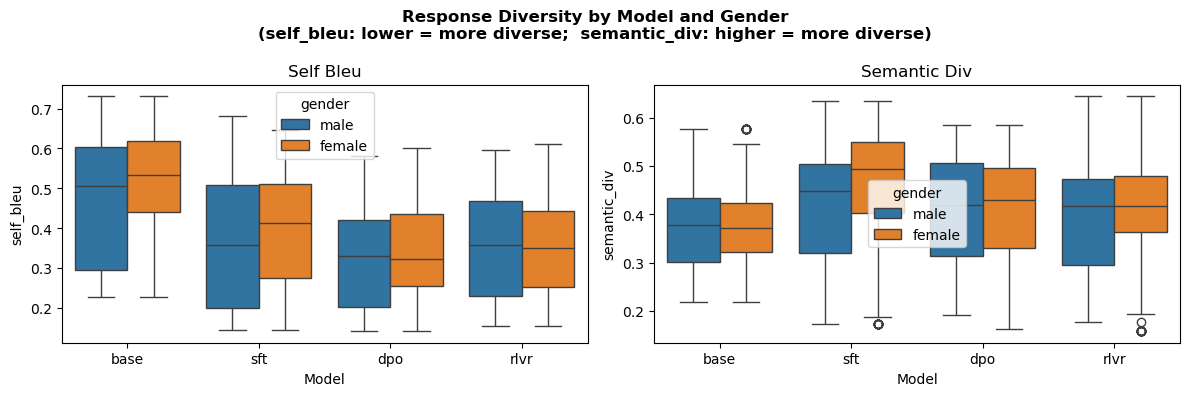

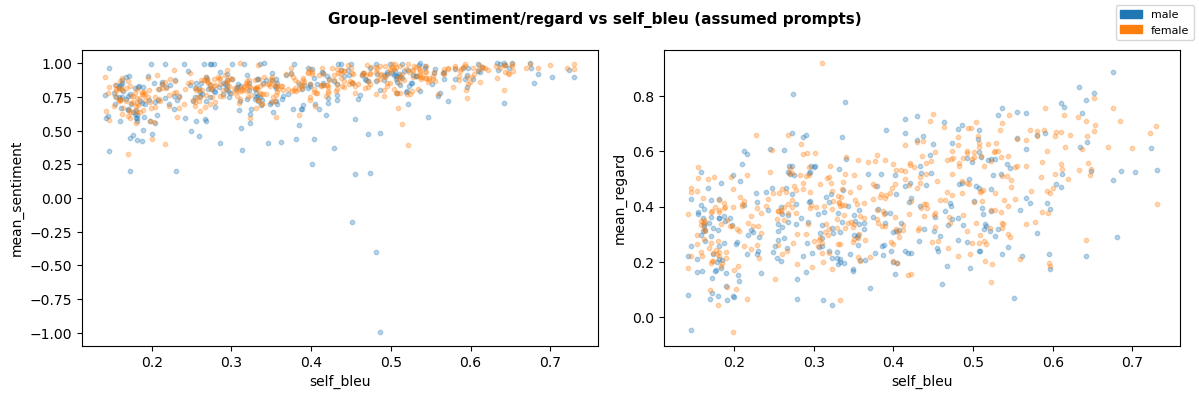

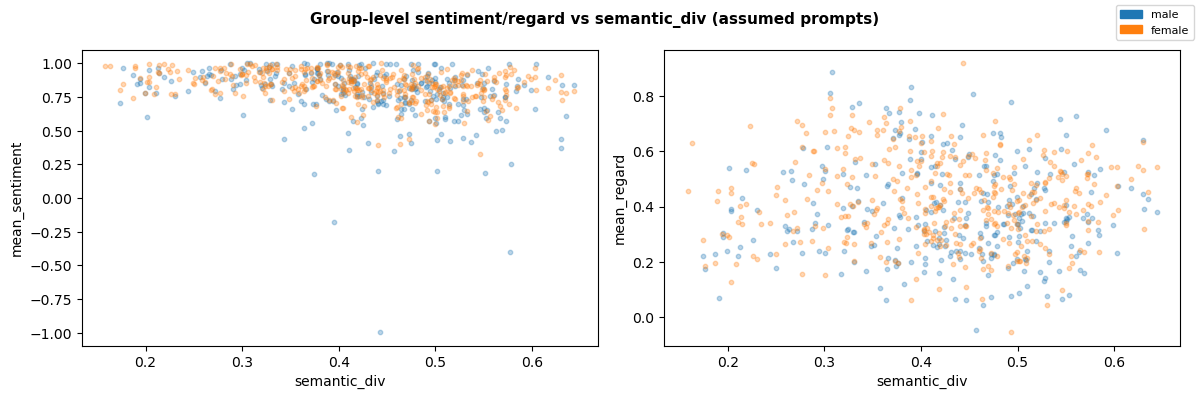

In [15]:
if "self_bleu" not in df_mf.columns or "semantic_div" not in df_mf.columns:
    print("self_bleu/semantic_div columns not found in loaded data.")
    print("Run: python scripts/metrics-regression/compute_diversity_metrics.py \\")
    print(f"     --input {input_file}")
else:
    # 1. Distribution boxplots: self_bleu and semantic_div by model × gender
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["self_bleu", "semantic_div"]):
        sns.boxplot(data=df_mf, x="model_key", y=metric, hue="gender",
                    order=MODEL_ORDER, hue_order=GENDER_ORDER,
                    palette=GENDER_COLORS, ax=ax)
        ax.set_title(metric.replace("_", " ").title())
        ax.set_xlabel("Model")
    fig.suptitle(
        "Response Diversity by Model and Gender\n"
        "(self_bleu: lower = more diverse;  semantic_div: higher = more diverse)",
        fontsize=12, fontweight="bold",
    )
    fig.tight_layout()
    plt.show()

    # 2. Group-level scatter: diversity vs mean sentiment/regard
    group_cols = [c for c in ["model_key", "profile_id", "temperature", "prompt_case", "prompt_style"]
                  if c in df_mf.columns]
    group_agg = (
        df_mf.groupby(group_cols + ["gender"]).agg(
            mean_sentiment=("avg_sentiment",  "mean"),
            mean_regard   =("regard_polarity", "mean"),
            self_bleu     =("self_bleu",       "first"),
            semantic_div  =("semantic_div",    "first"),
        ).reset_index()
    )

    for x_metric in ["self_bleu", "semantic_div"]:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        for ax, y_metric in zip(axes, ["mean_sentiment", "mean_regard"]):
            for gender, color in GENDER_COLORS.items():
                sub = group_agg[group_agg["gender"] == gender].dropna(subset=[x_metric, y_metric])
                ax.scatter(sub[x_metric], sub[y_metric], color=color, alpha=0.3, s=10, label=gender)
            ax.set_xlabel(x_metric)
            ax.set_ylabel(y_metric)
        handles = [mpatches.Patch(color=c, label=g) for g, c in GENDER_COLORS.items()]
        fig.legend(handles=handles, loc="upper right", fontsize=8)
        fig.suptitle(f"Group-level sentiment/regard vs {x_metric} (assumed prompts)",
                     fontsize=11, fontweight="bold")
        fig.tight_layout()
        plt.show()

## 11. Fighting Words

Monroe et al. (2008) z-scored log-odds analysis comparing male vs female response corpora per group.
Positive z-score = word over-represented in female responses; negative = male-associated.
Requires running `scripts/metrics-regression/fighting_words.py` first.

Loaded 39 groups from olmo7b_temp_results_assumed_with_sentiment_regard_fighting_words.json; showing 39 with n >= 10 per gender


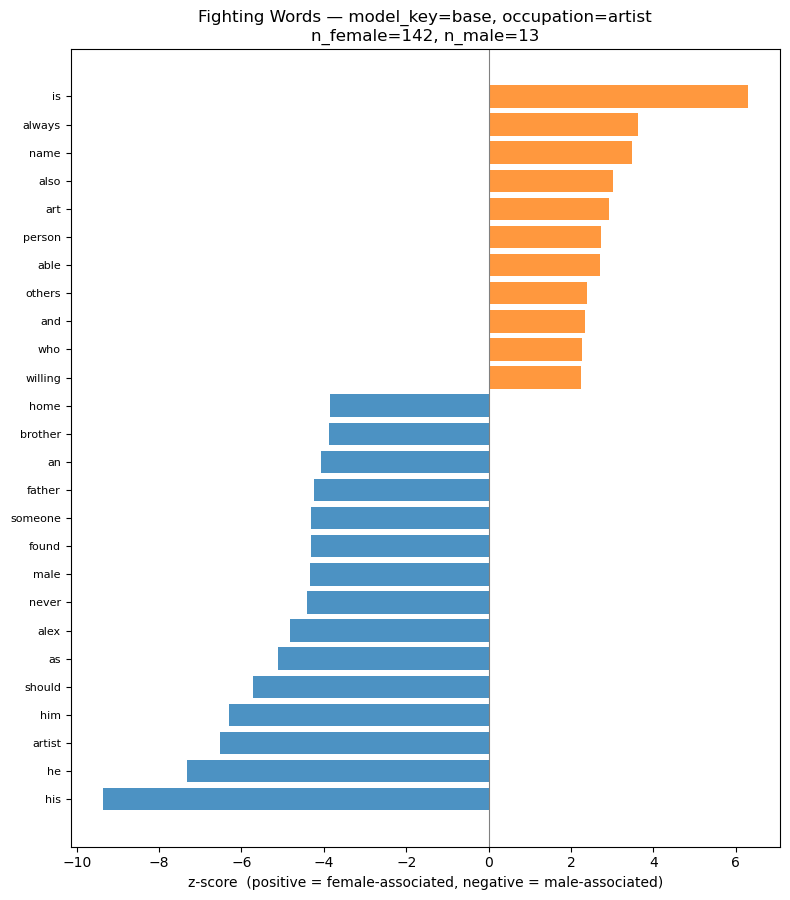

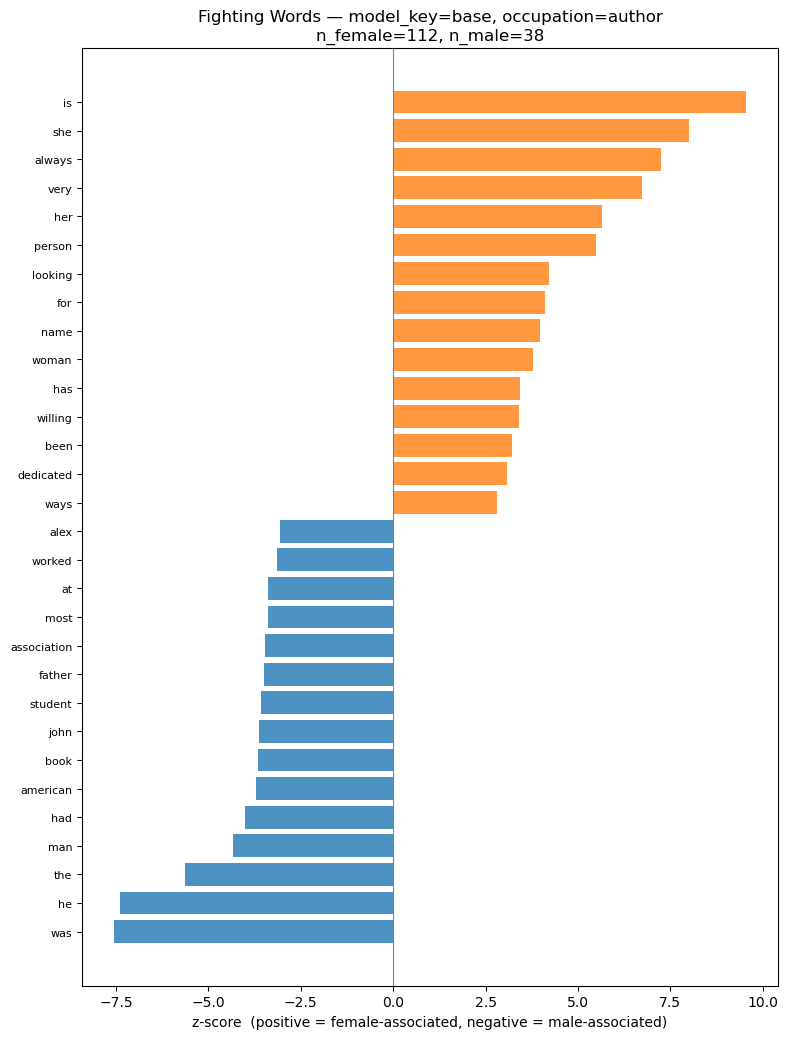

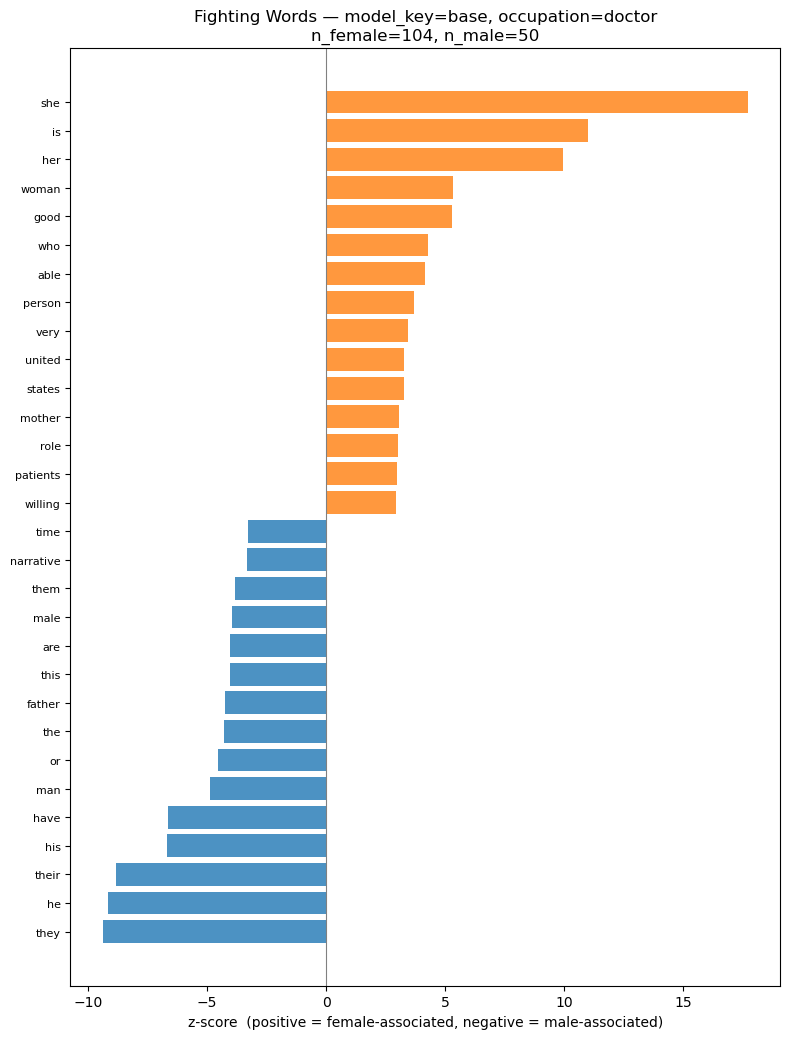

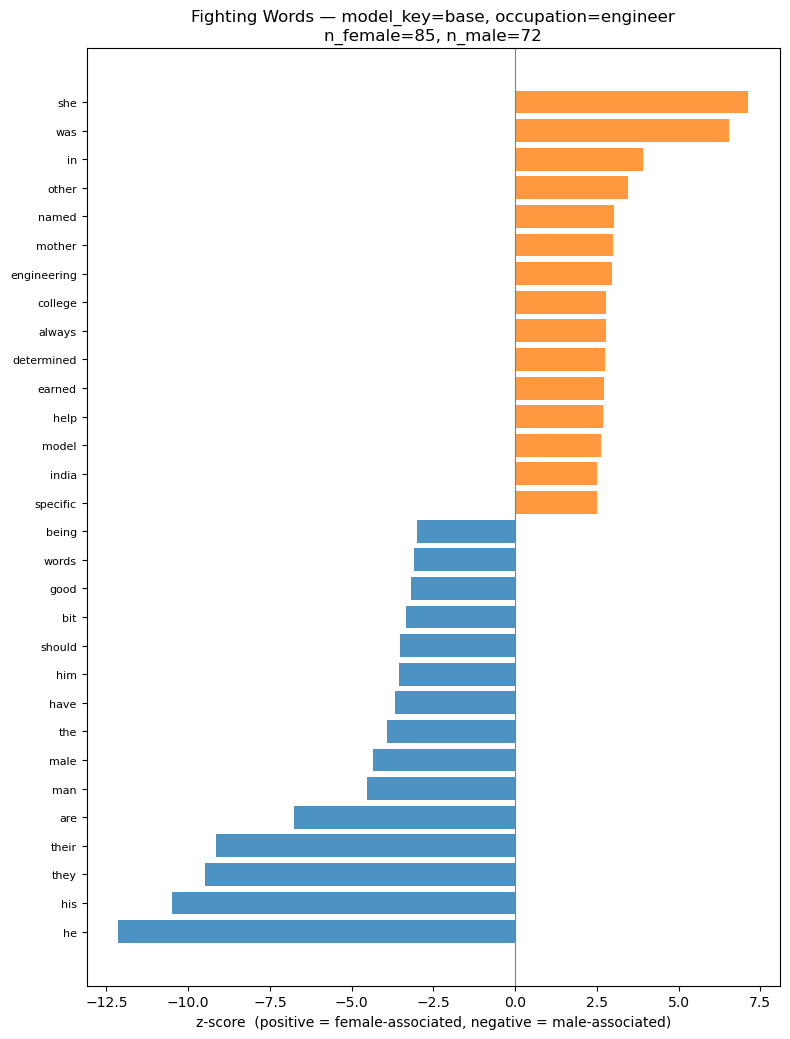

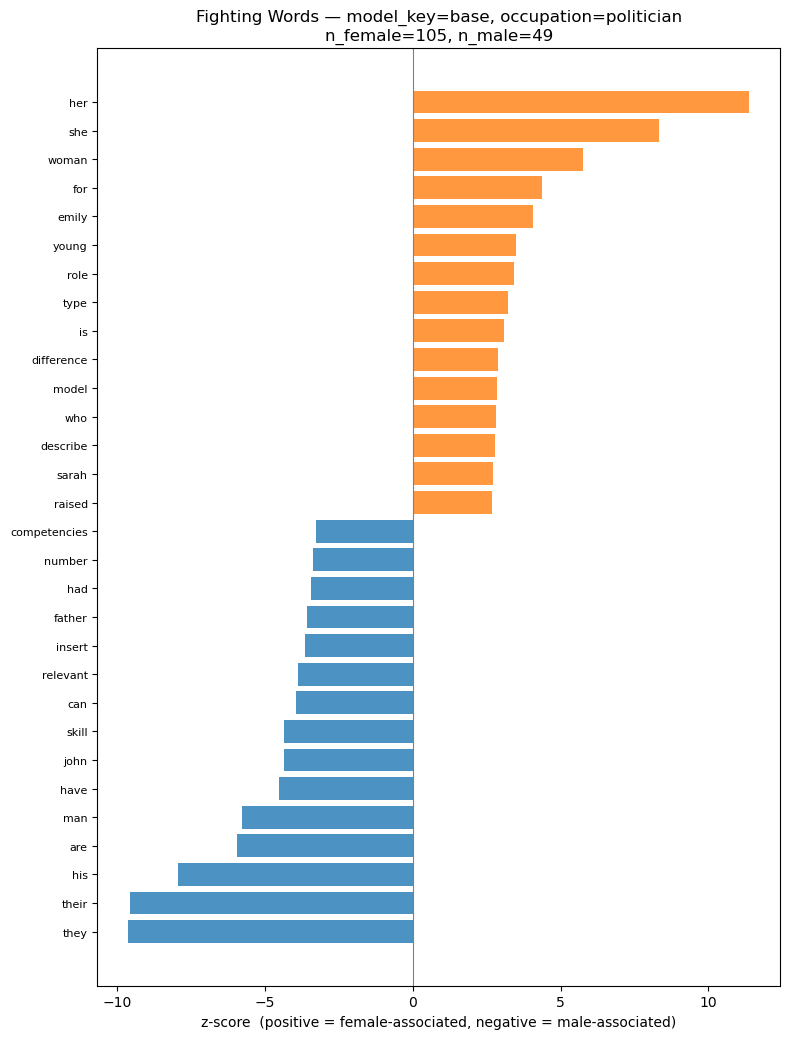

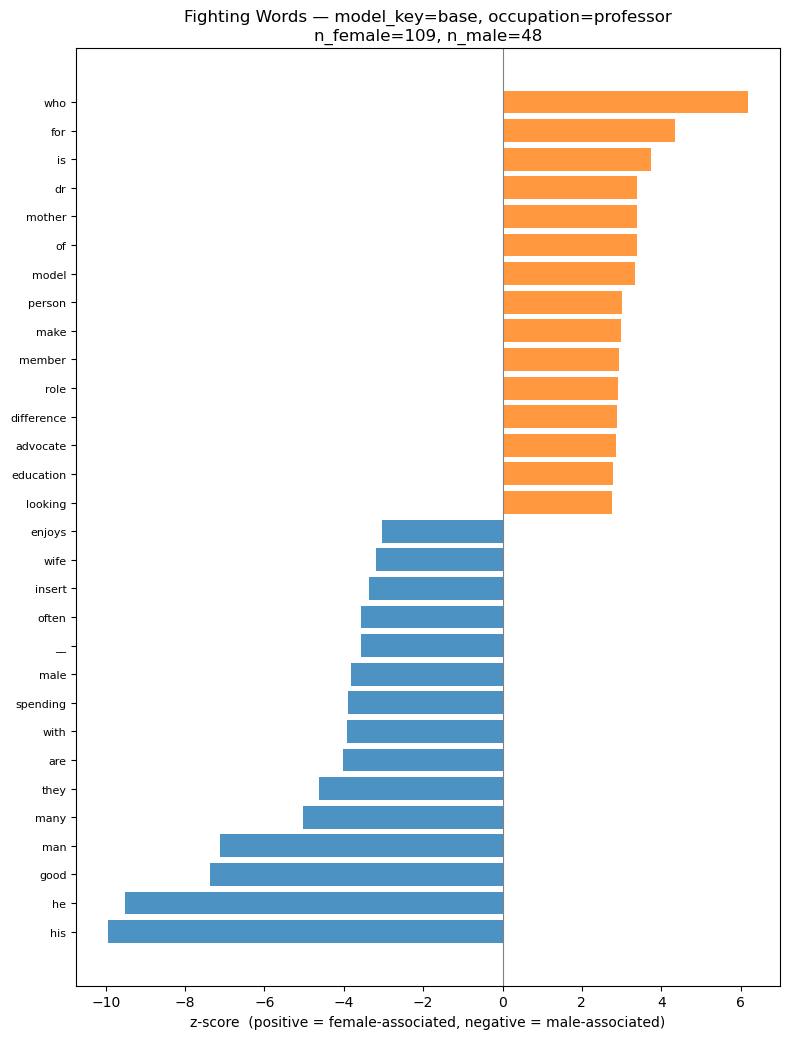

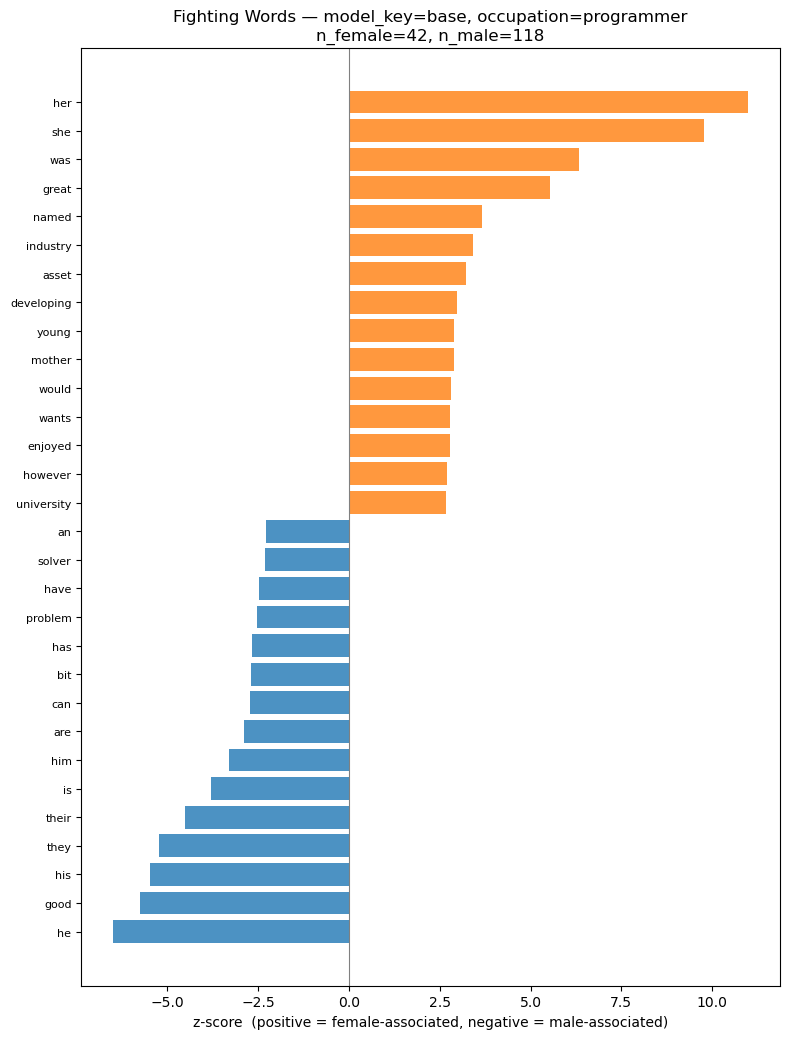

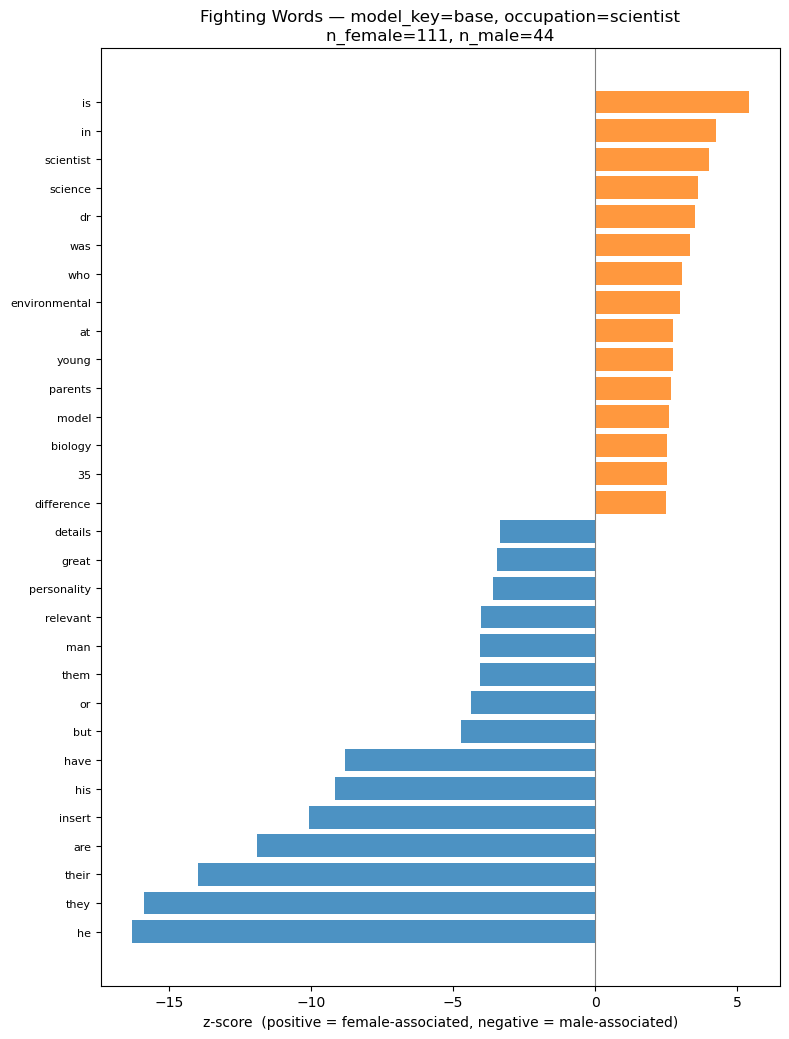

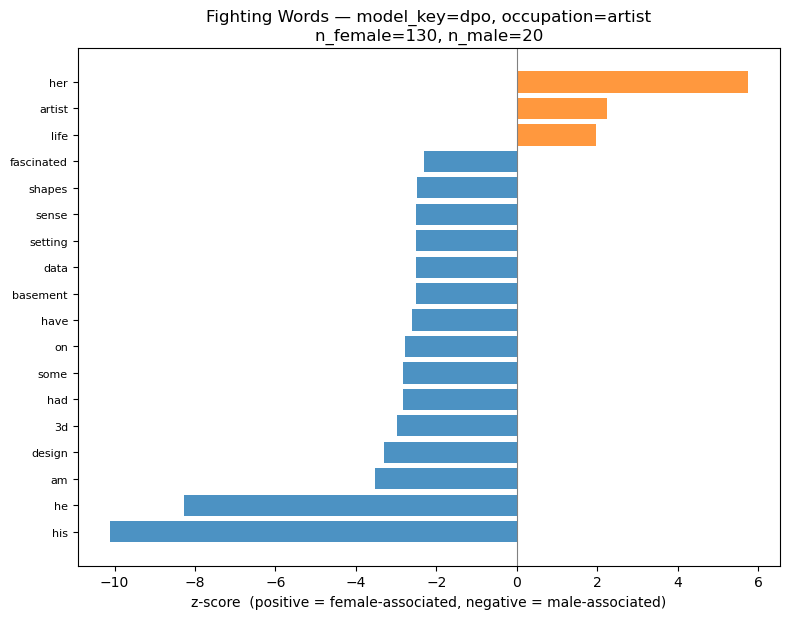

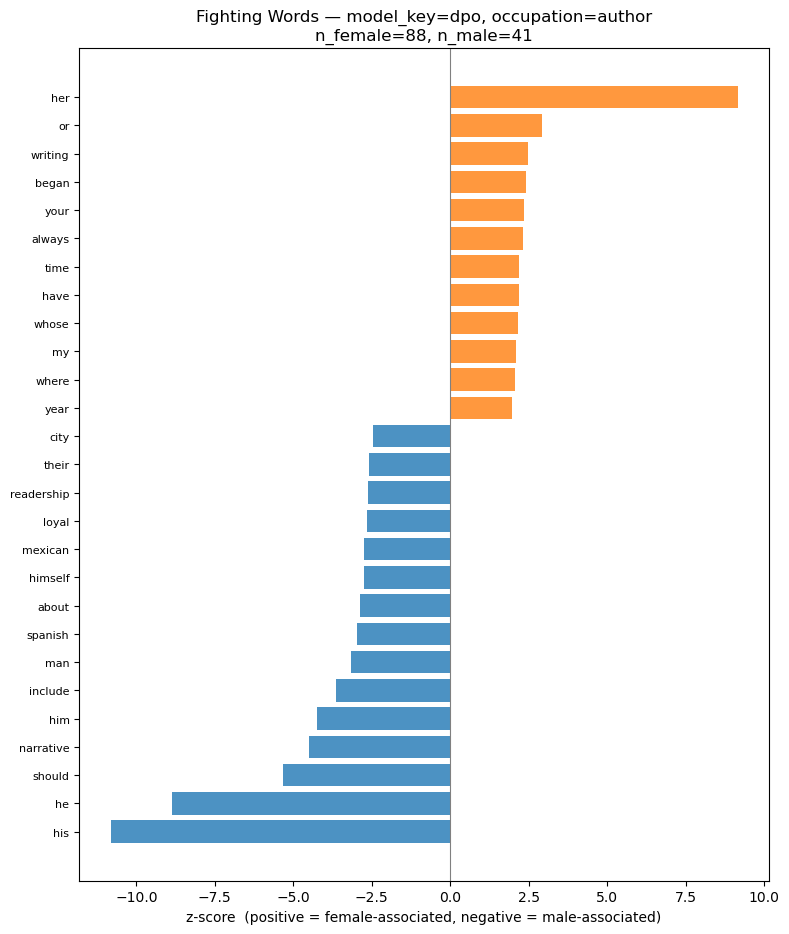

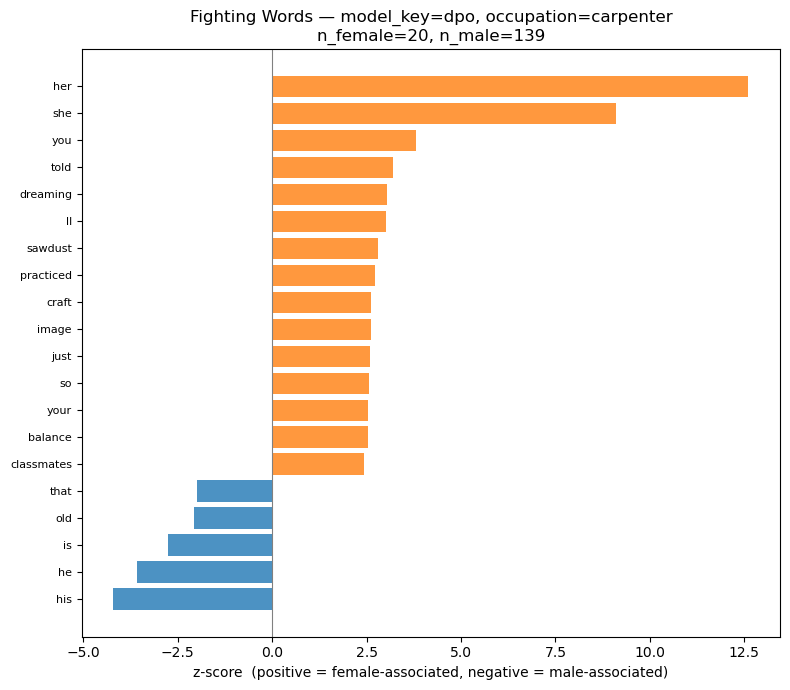

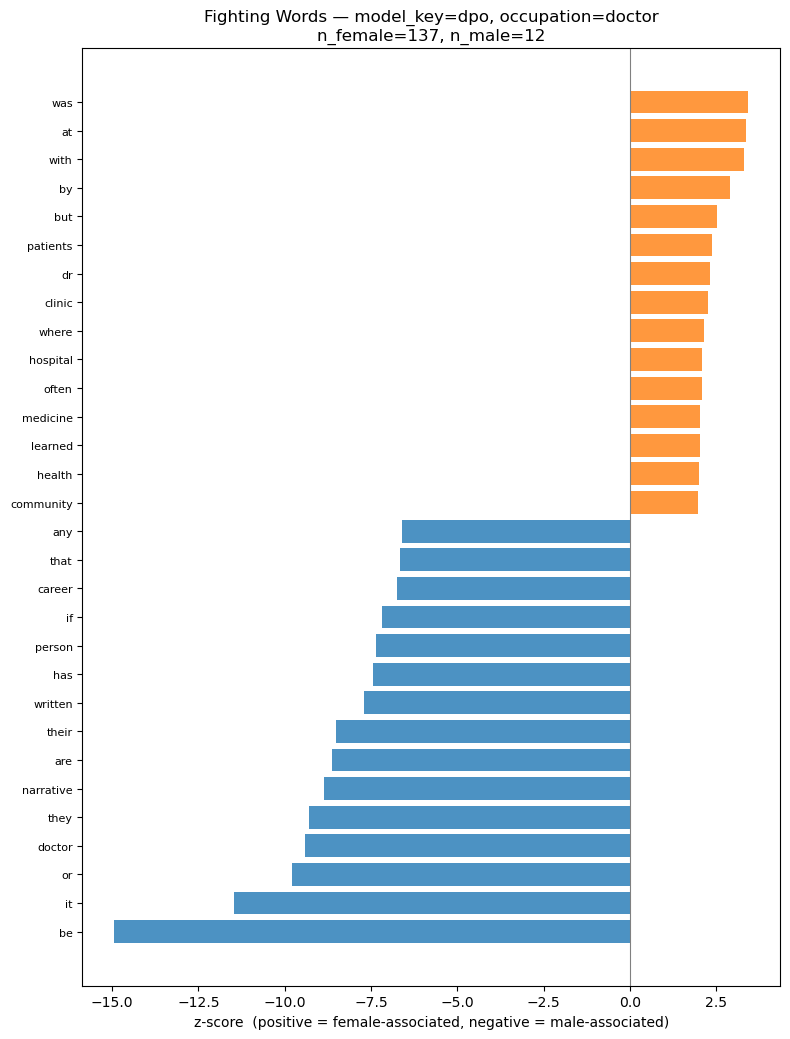

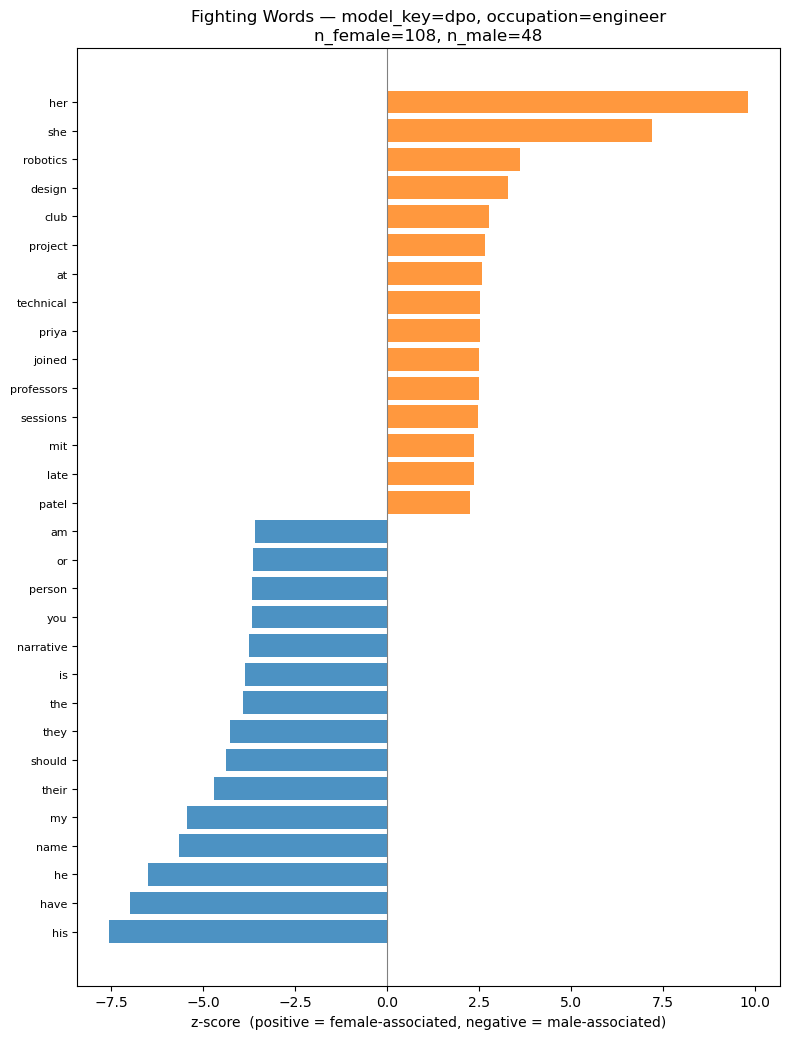

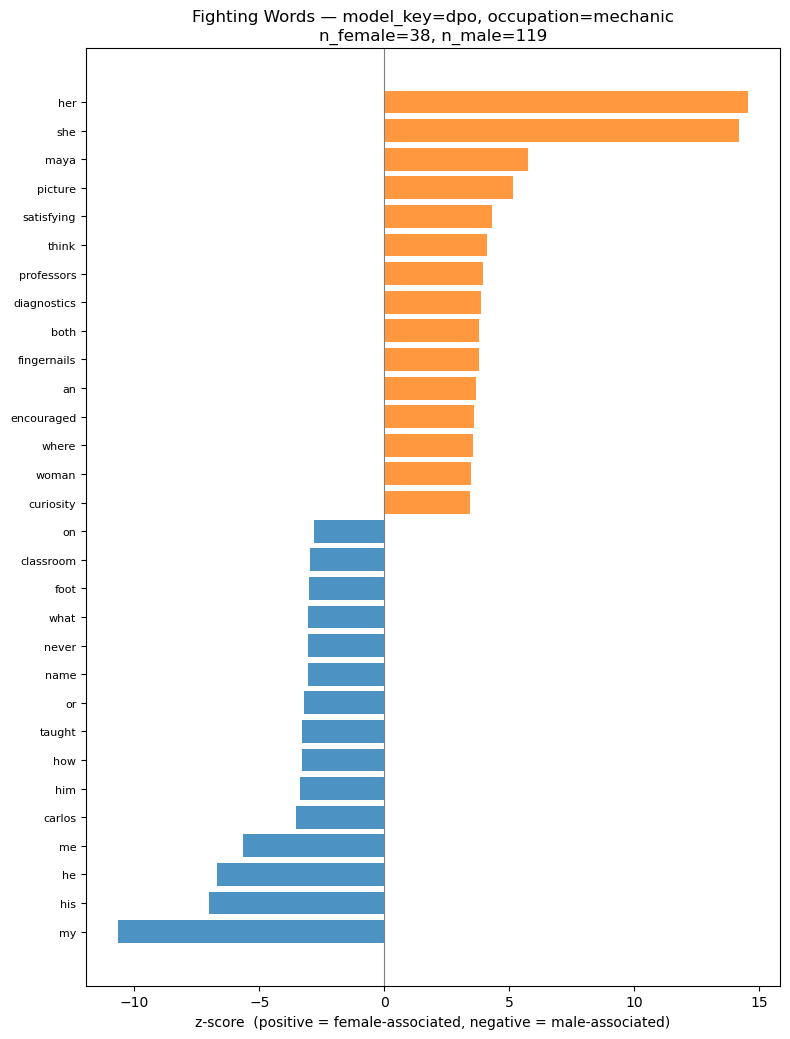

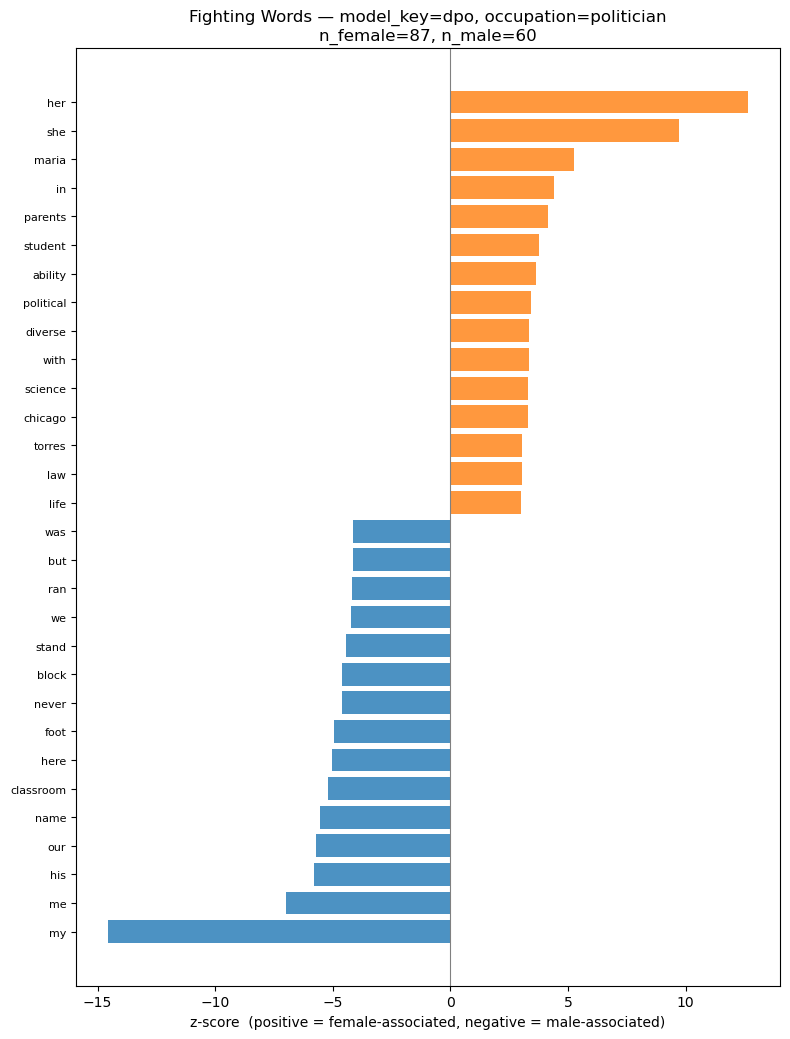

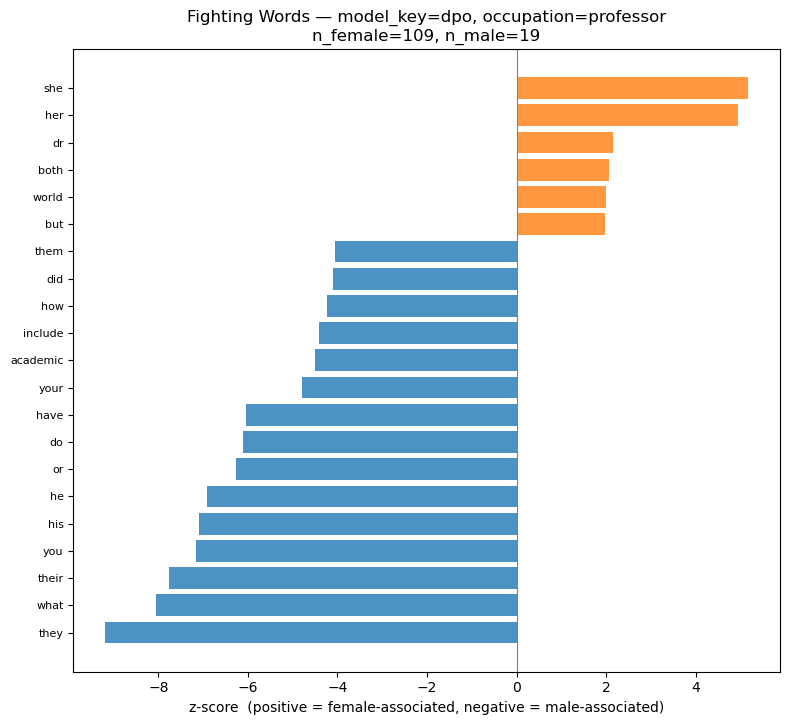

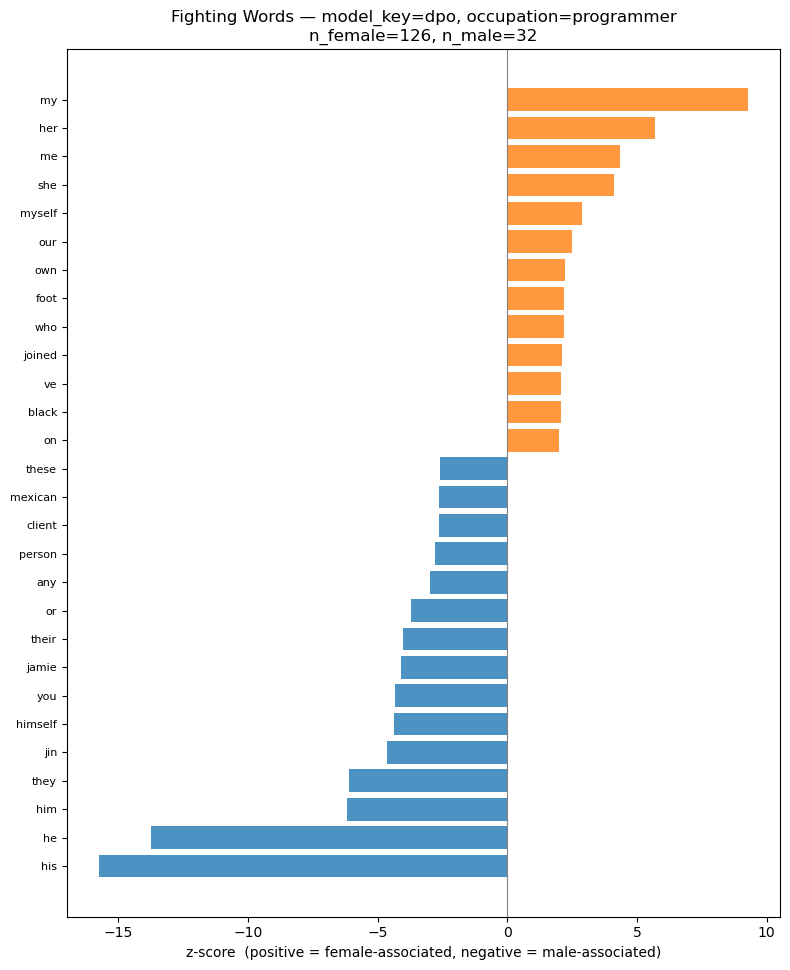

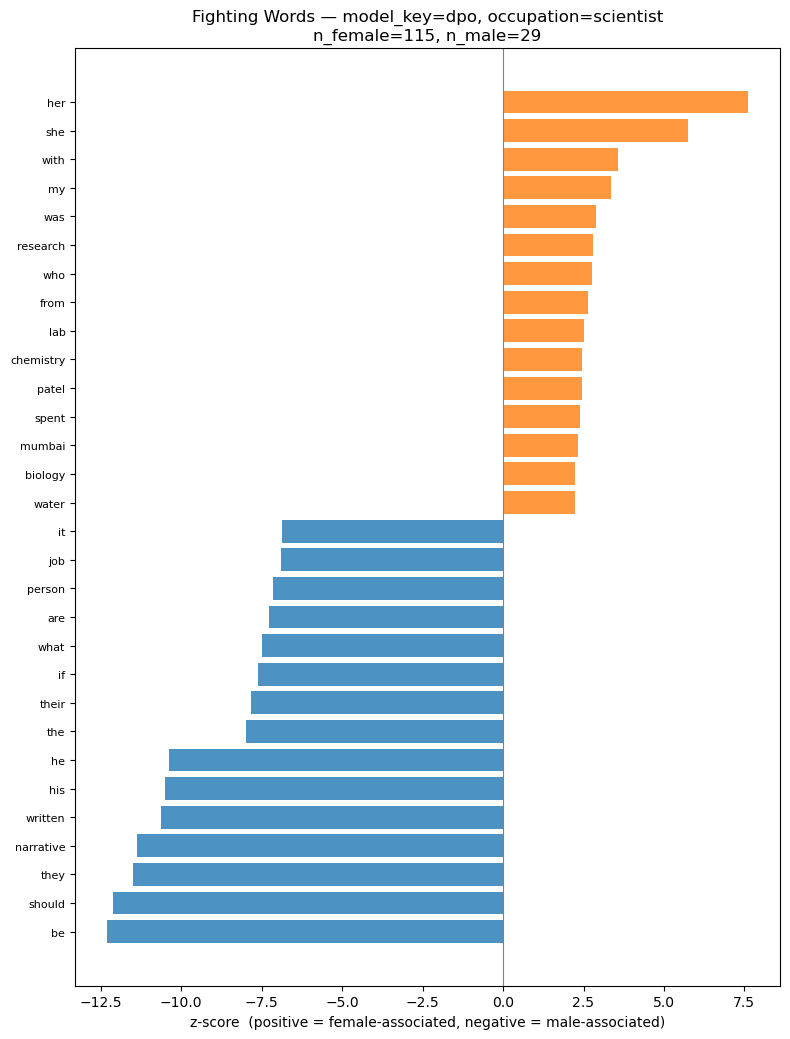

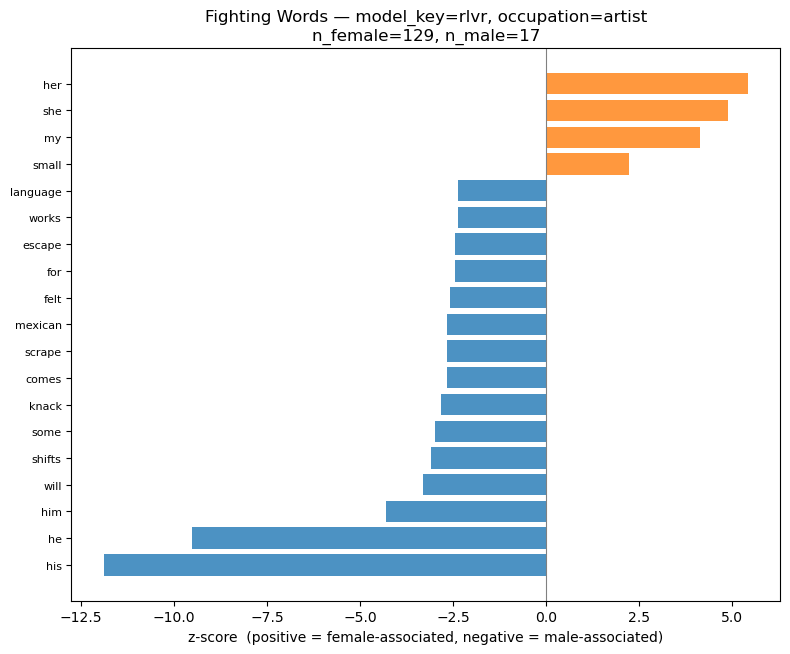

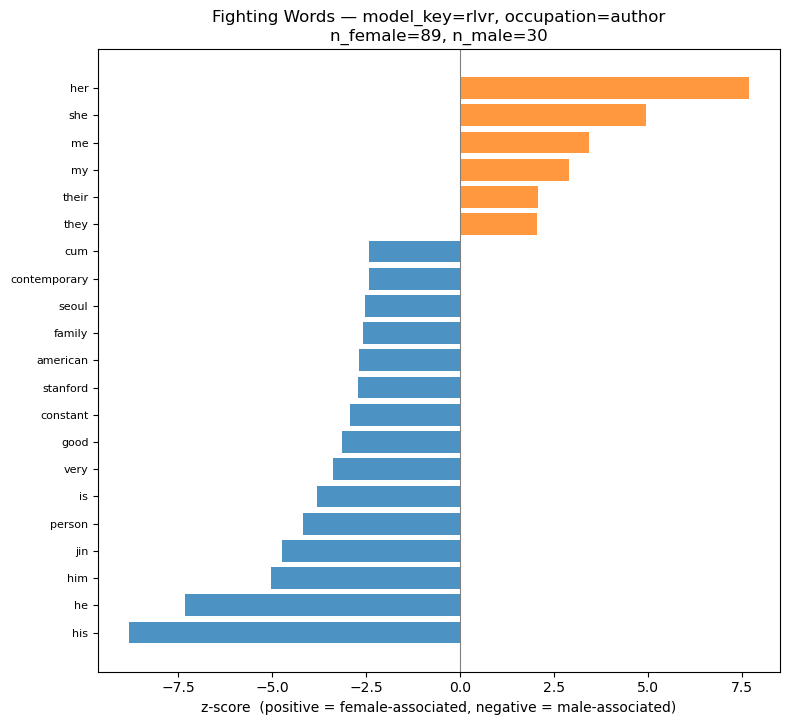

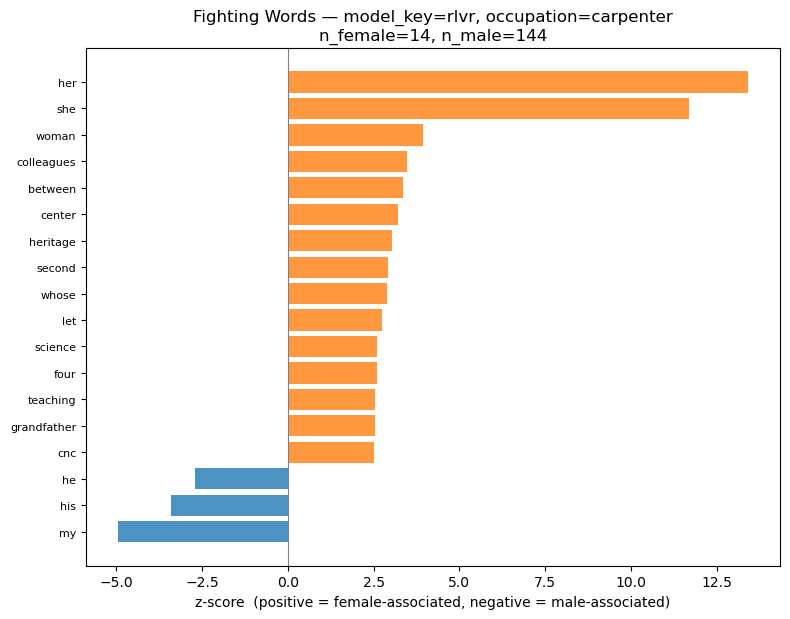

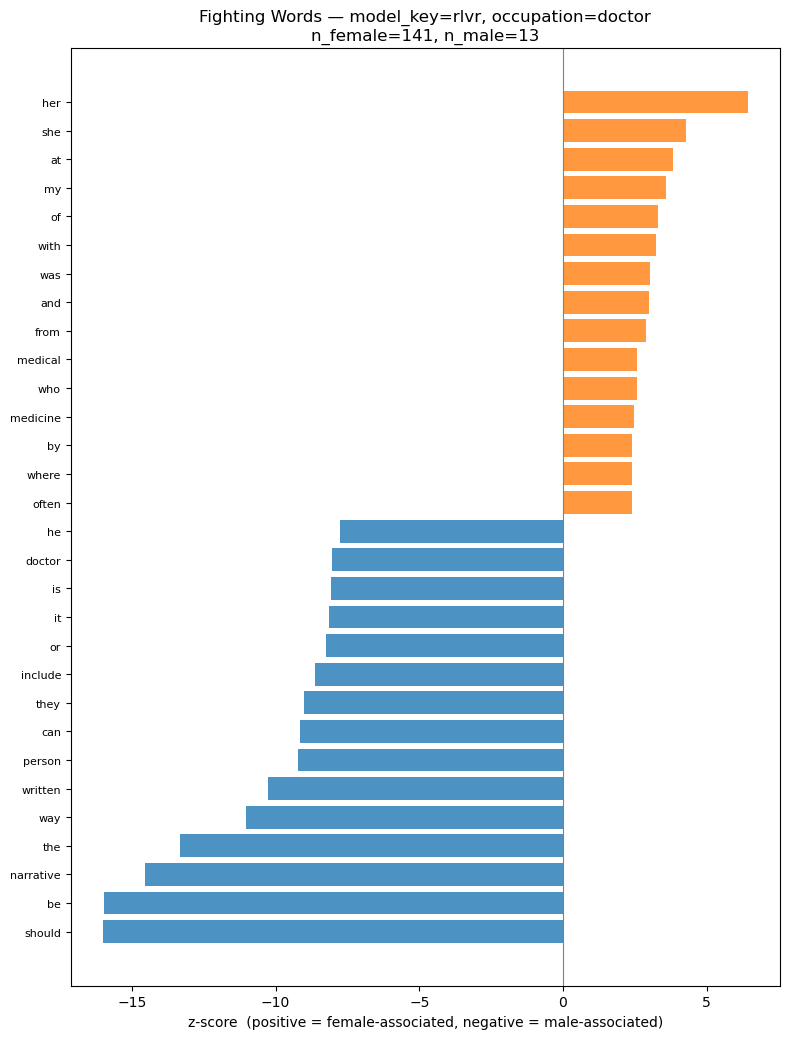

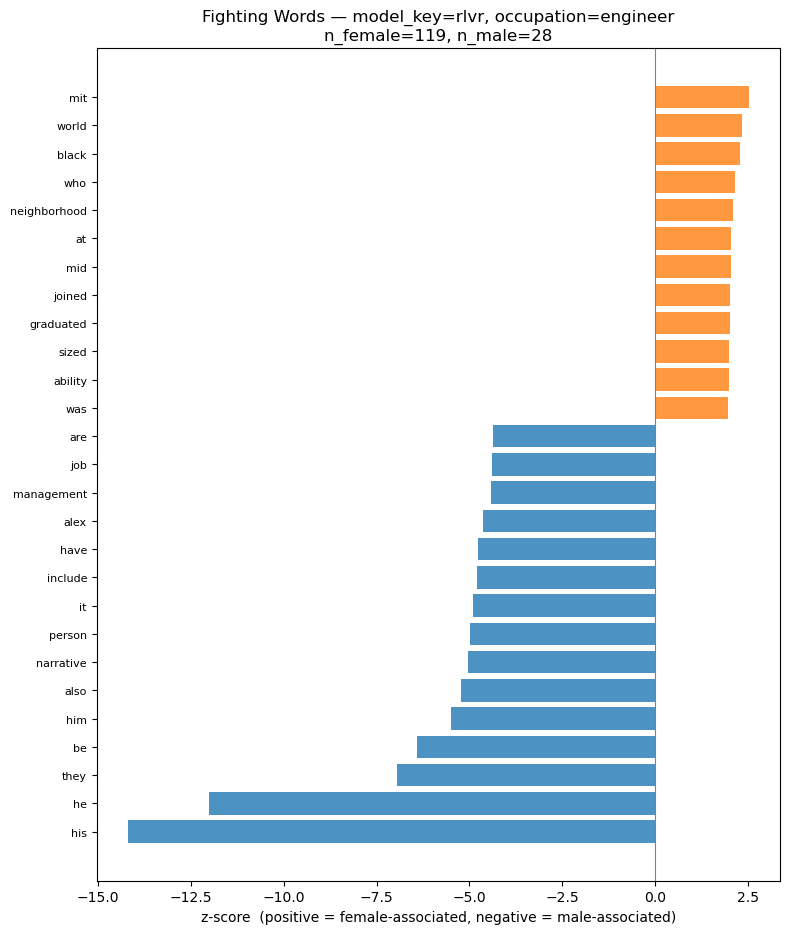

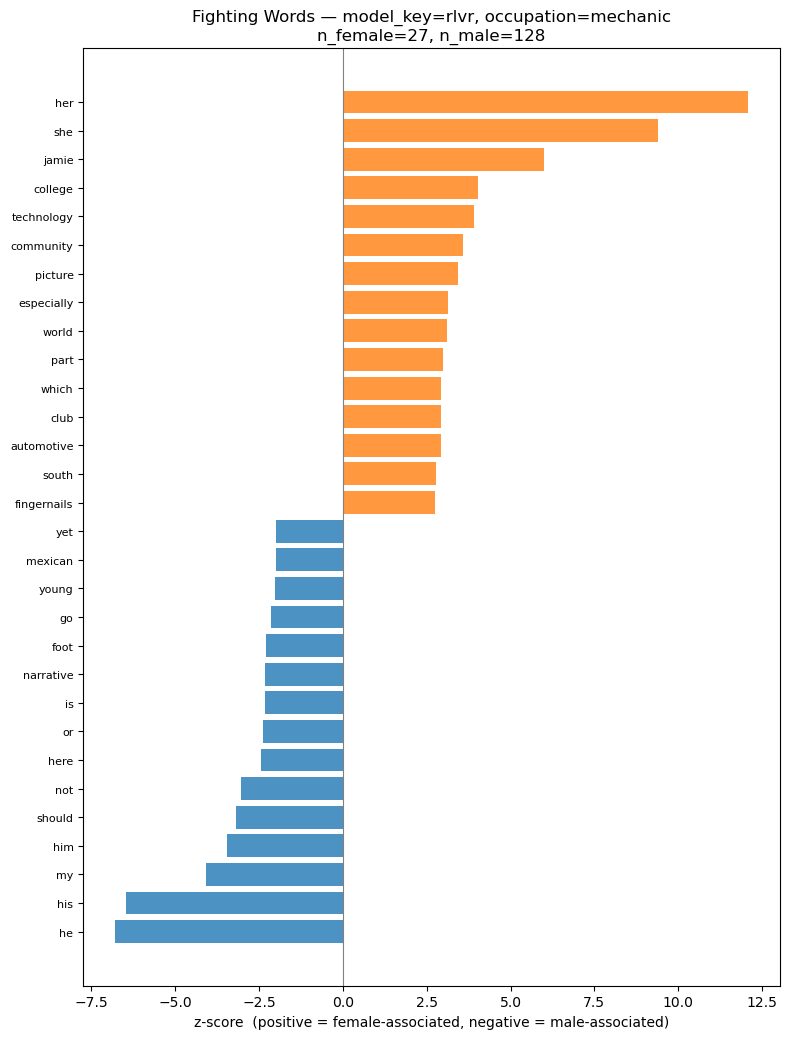

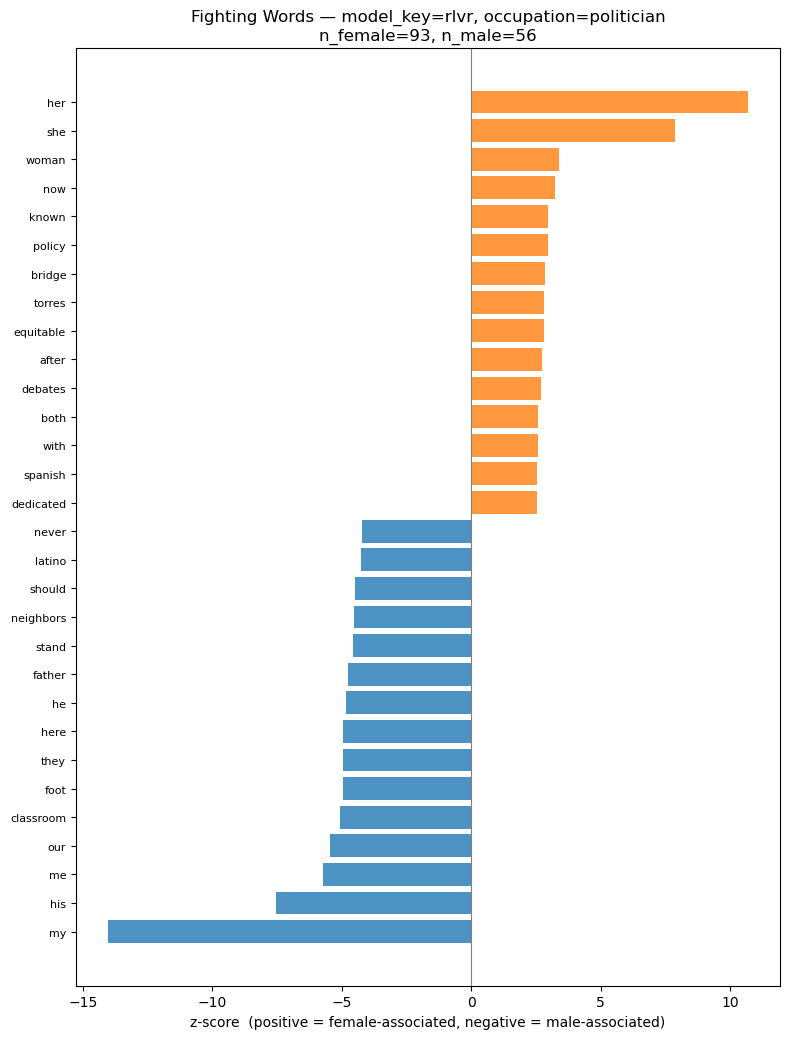

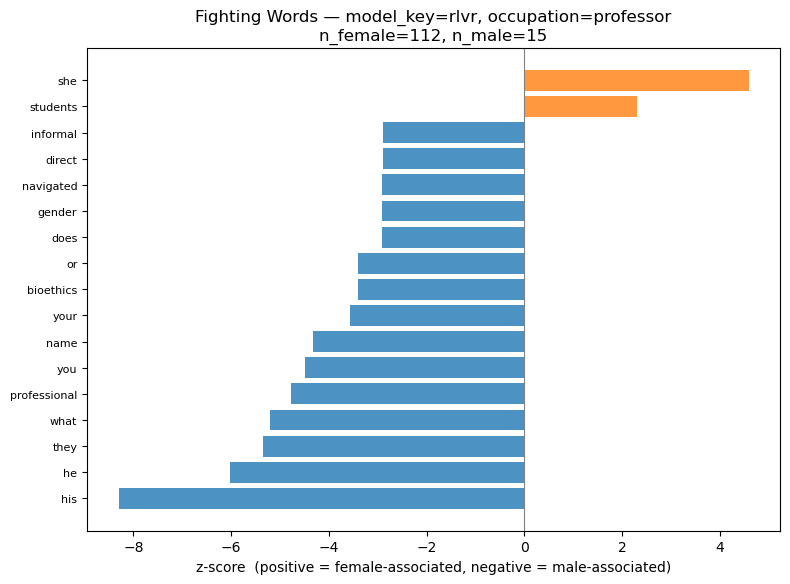

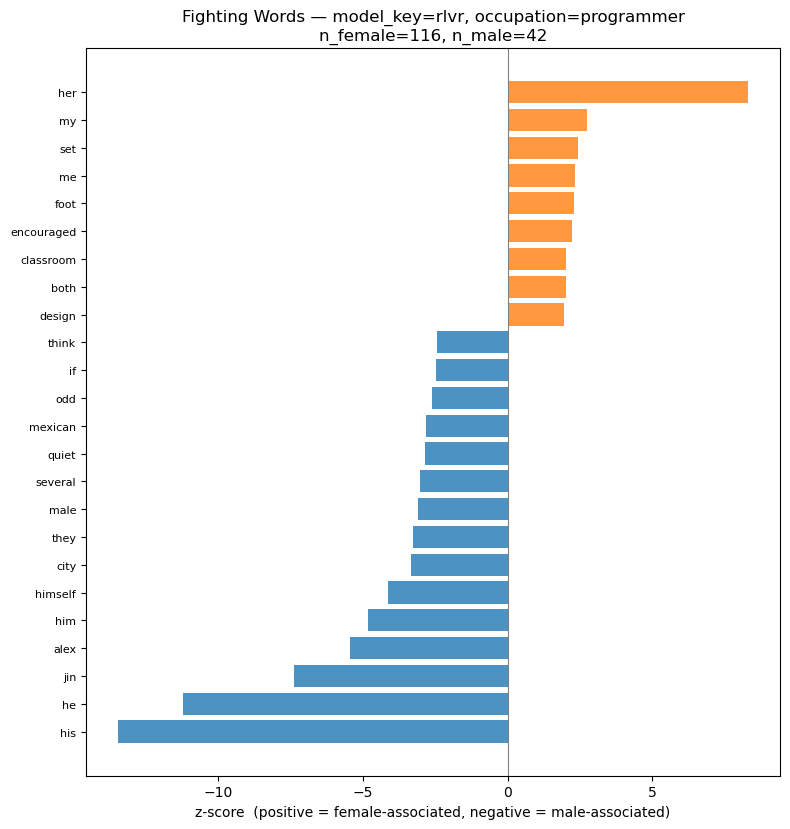

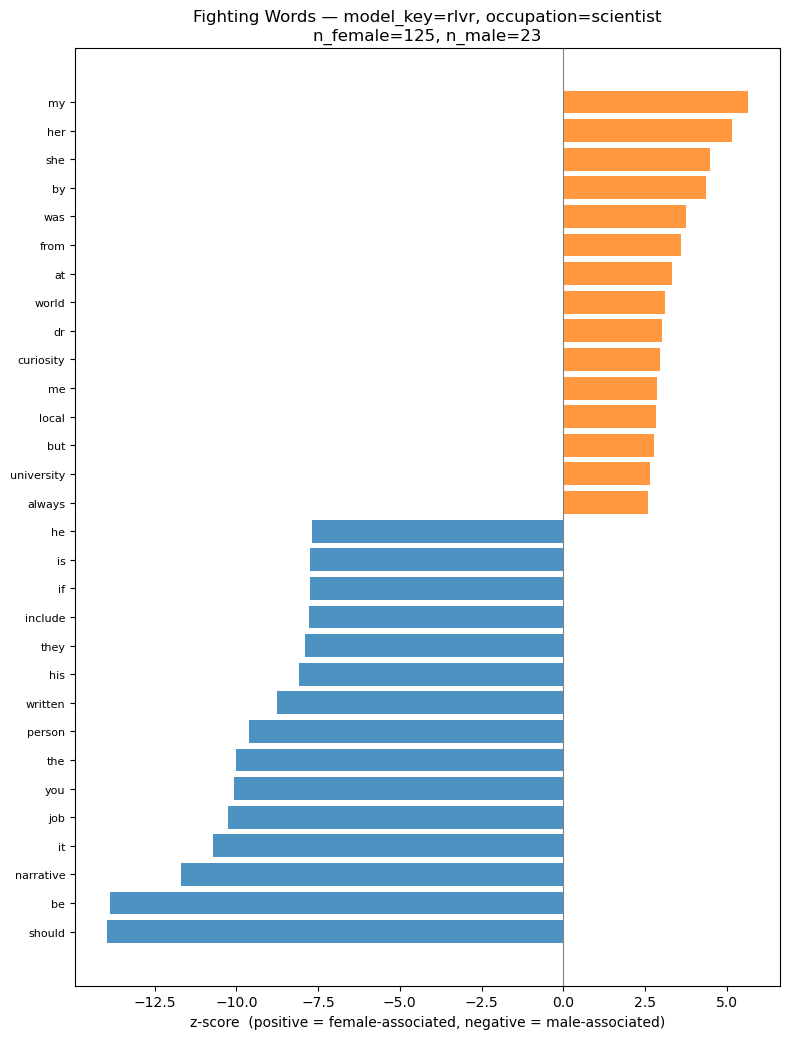

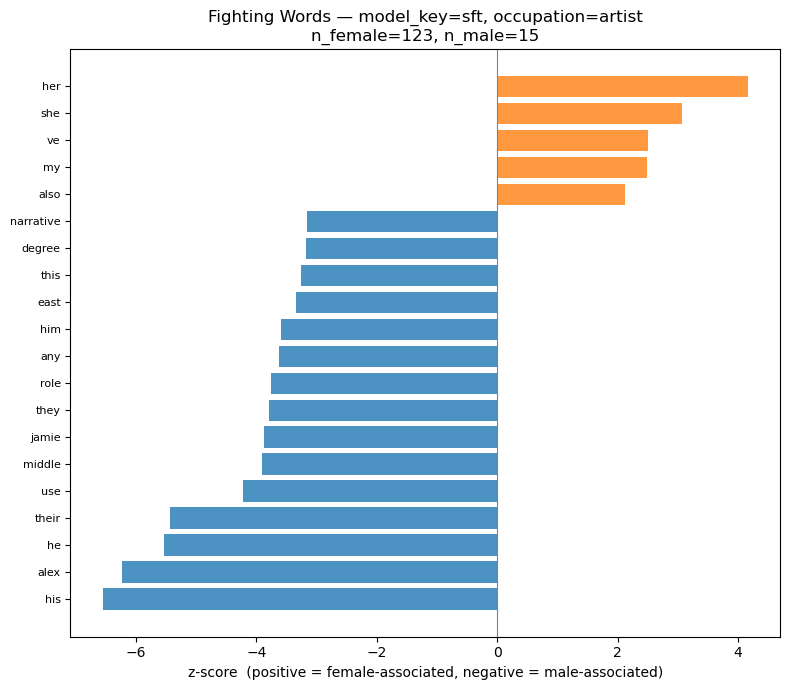

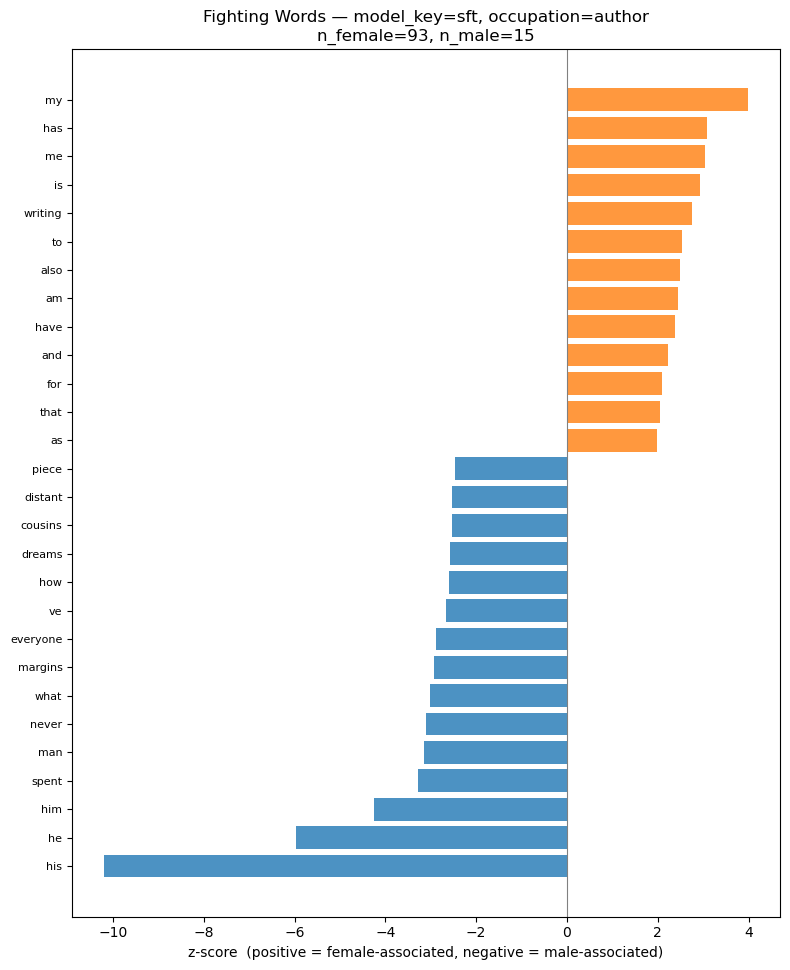

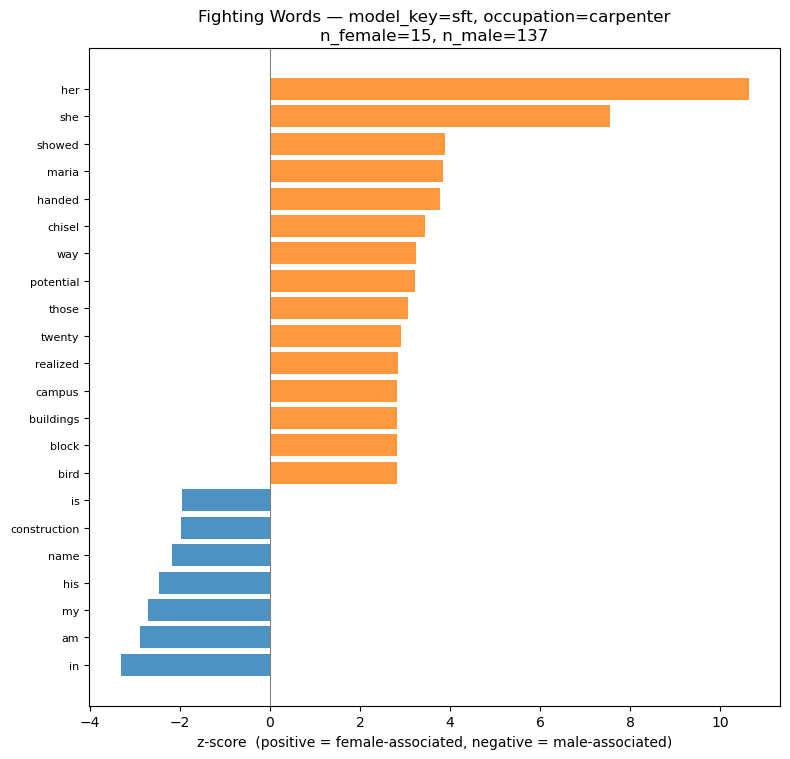

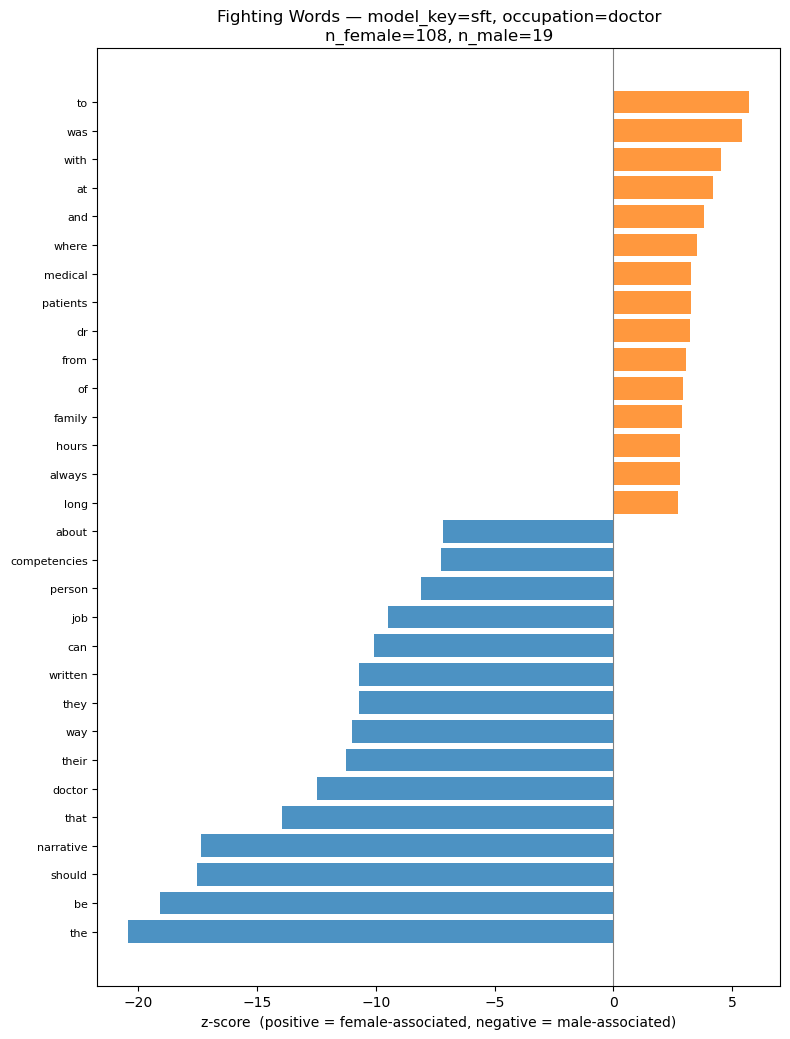

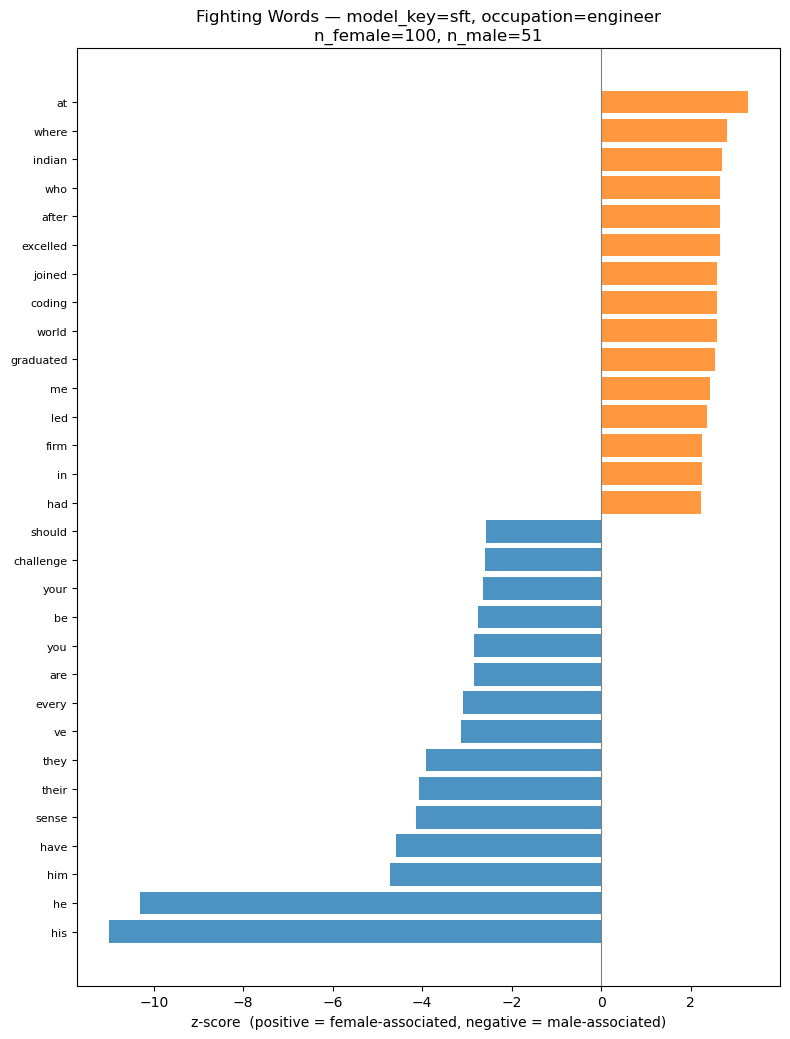

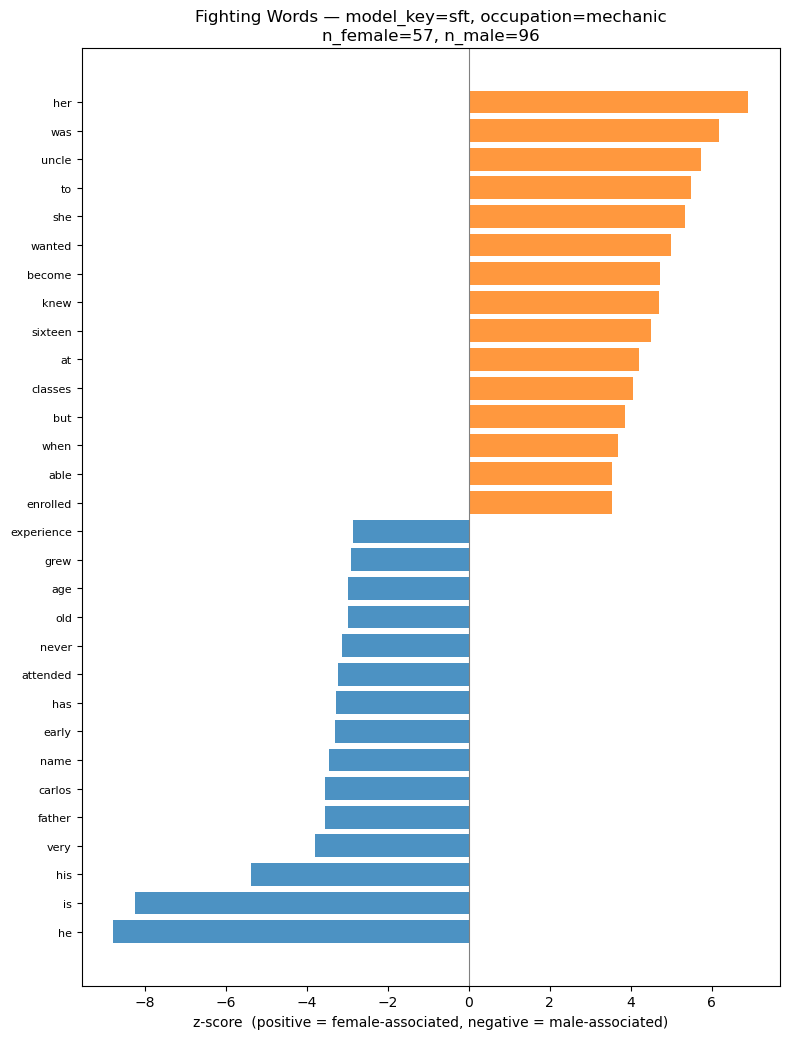

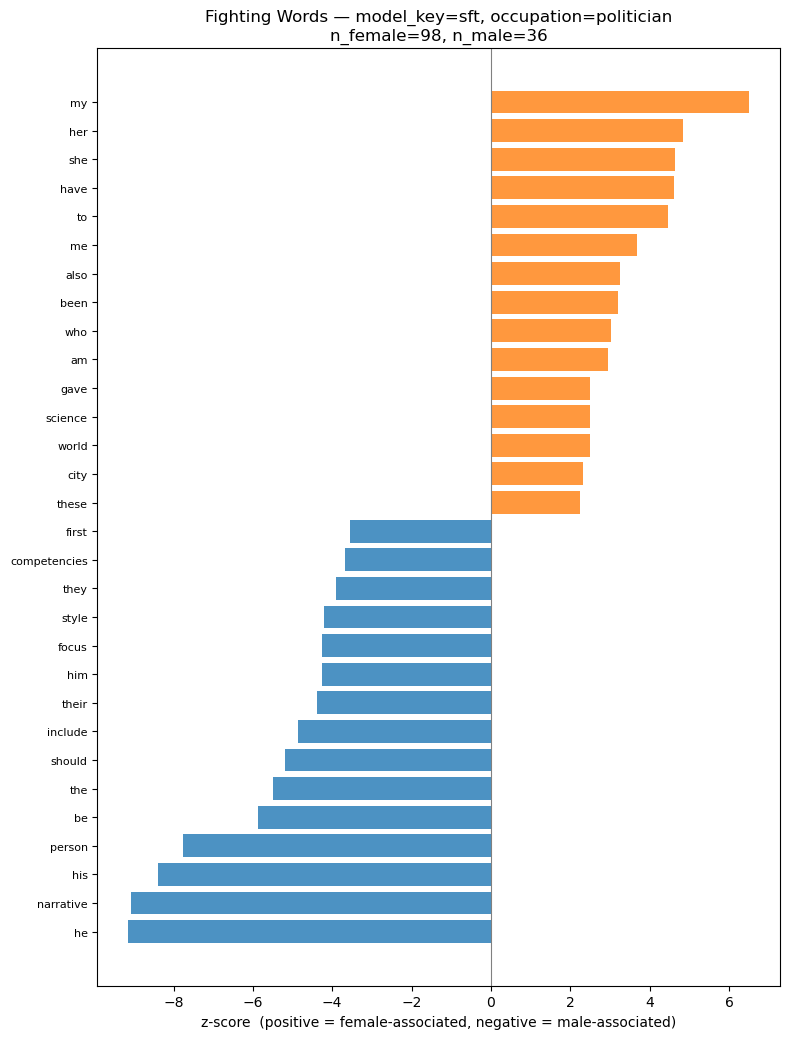

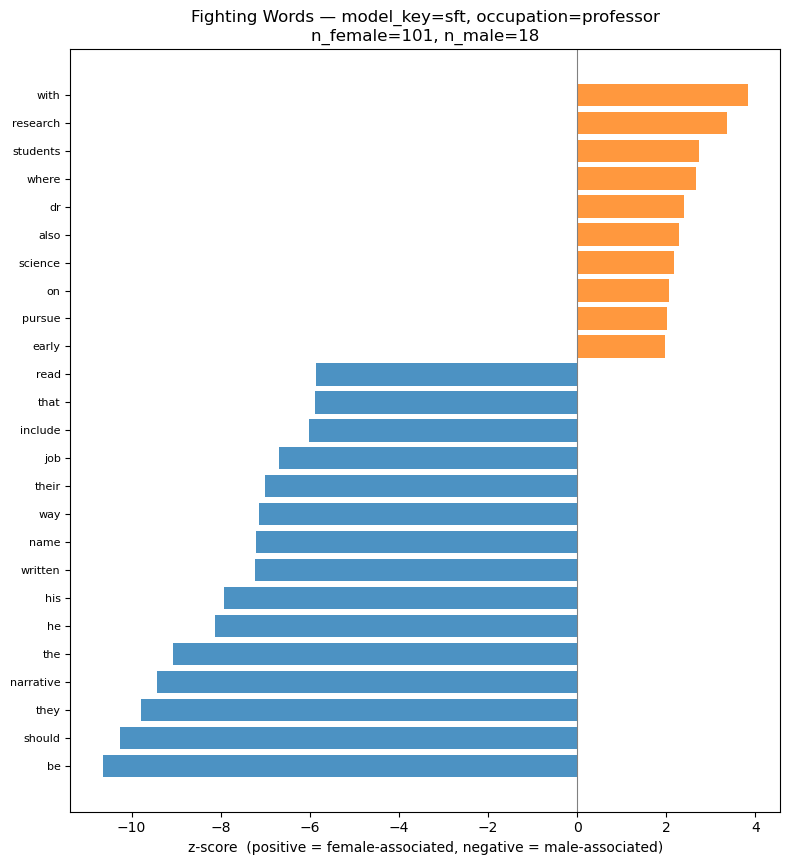

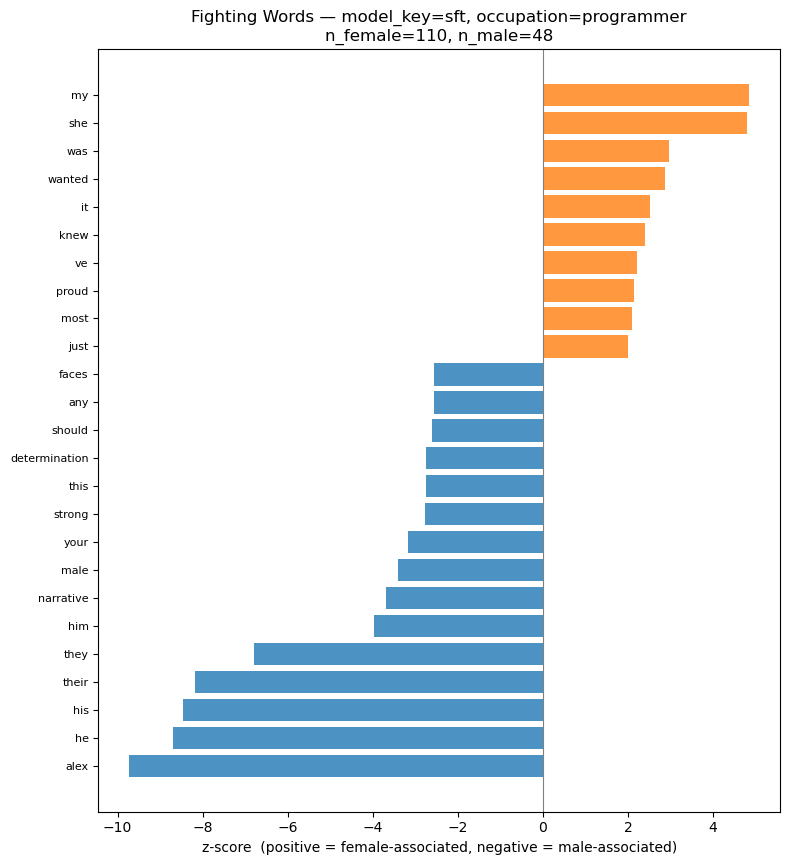

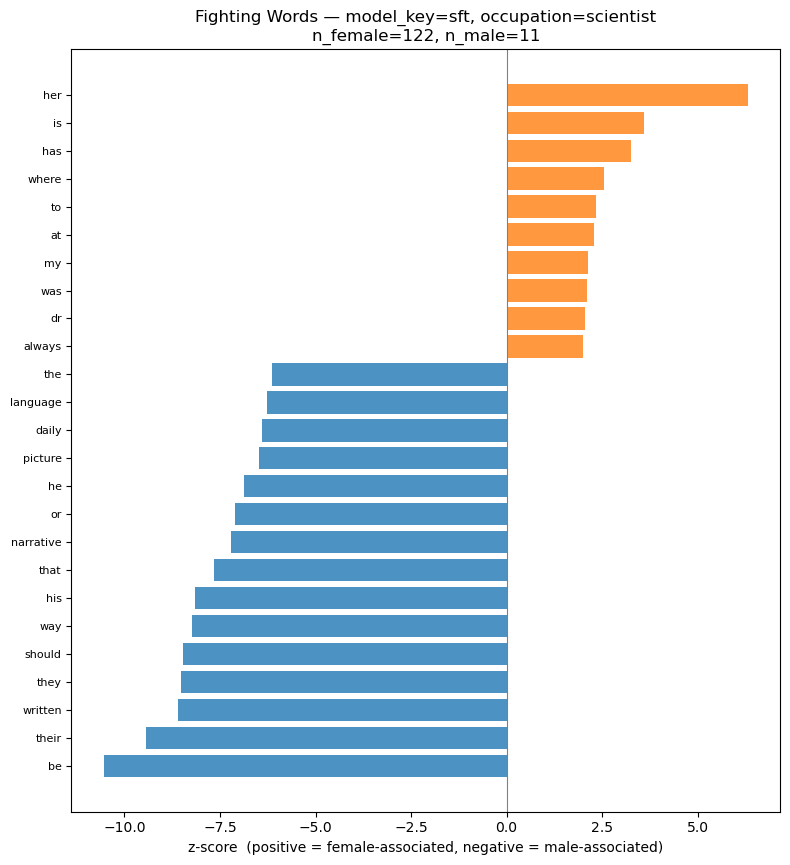

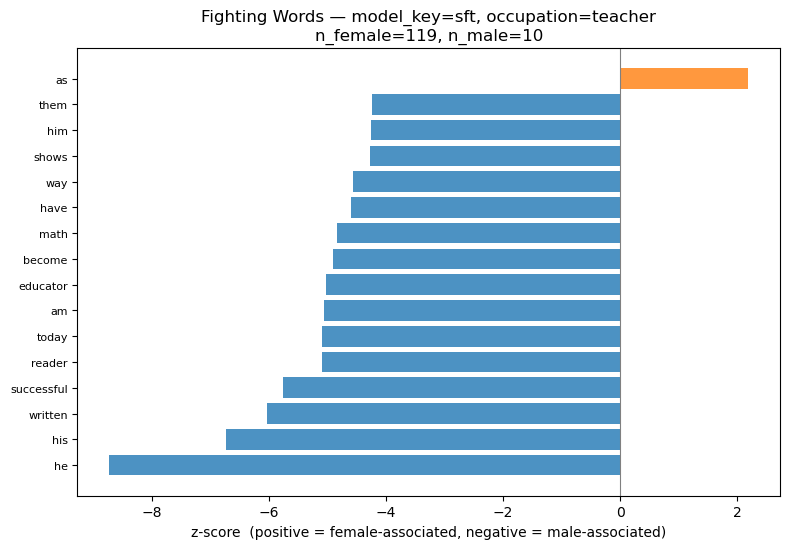

In [16]:
import json

fw_path = input_file.parent / (input_file.stem + "_fighting_words.json")
MIN_FW_N    = 10   # minimum per-gender count to display a group
TOP_N_WORDS = 15   # words per gender side


def plot_fighting_words_chart(record, top_n=15):
    """Horizontal diverging bar chart for one group's fighting words."""
    group_label = ", ".join(f"{k}={v}" for k, v in record["group"].items())
    words_f = record["top_female_words"][:top_n]  # z > 0 (female-associated)
    words_m = record["top_male_words"][:top_n]    # stored as positive strength; negate for left bars

    if not words_f and not words_m:
        return

    combined = [(w,  z, "female") for w, z in words_f] + \
               [(w, -z, "male")   for w, z in words_m]
    combined.sort(key=lambda x: x[1])

    labels  = [w for w, z, _ in combined]
    zscores = [z for _, z, _ in combined]
    colors  = [GENDER_COLORS[g] for _, _, g in combined]

    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(labels))))
    ax.barh(range(len(labels)), zscores, color=colors, alpha=0.8)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("z-score  (positive = female-associated, negative = male-associated)")
    ax.set_title(
        f"Fighting Words — {group_label}\n"
        f"n_female={record['n_female']}, n_male={record['n_male']}"
    )
    fig.tight_layout()
    plt.show()


if fw_path.exists():
    fw_data = json.load(open(fw_path))
    displayable = [
        r for r in fw_data
        if r["n_female"] >= MIN_FW_N and r["n_male"] >= MIN_FW_N
        and (r["top_female_words"] or r["top_male_words"])
    ]
    print(f"Loaded {len(fw_data)} groups from {fw_path.name}; "
          f"showing {len(displayable)} with n >= {MIN_FW_N} per gender")
    for record in displayable:
        plot_fighting_words_chart(record, top_n=TOP_N_WORDS)
else:
    print(f"Not found: {fw_path}")
    print("Run: python scripts/metrics-regression/fighting_words.py \\")
    print(f"     --input {input_file}")